In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import os, glob
import h5py

import sys
sys.path.append('../../')
import analysis_utils as utils
utils.load_plotting_setting()

import calc_gas_collision_spectrum as calc_gas

In [36]:
import importlib
importlib.reload(utils)
importlib.reload(calc_gas)

<module 'calc_gas_collision_spectrum' from '/Users/yuhan/work/nanospheres/gas_collisions/analysis_notebooks/sphere_20260215_final_analysis/../../calc_gas_collision_spectrum.py'>

## Overview

This notebook shows the reconstructed spectra for the background, Kr, Xe, and SF6 datasets.

In [56]:
search_window_length = 2**8
time_per_search = 200e-9 * search_window_length  # s

# ── Config ────────────────────────────────────────────────────────────────
# To plot a different sphere/run, change recon_file and gas_types below.
recon_file = r'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/gas_recon/sphere_20260215_gas_recon_all.h5py'
gas_types = ['xenon', 'krypton', 'sf6', 'background']

# Stage suffixes added by recon_histograms.py (used to identify base dataset names)
_stage_suffixes = (
    '_nocal', '_cal',
    '_nocuts', '_nocuts_nocal', '_nocuts_cal',
    '_hom_bal', '_hom_bal_nocal', '_hom_bal_cal',
    '_noise', '_noise_nocal', '_noise_cal',
    '_drive', '_drive_nocal', '_drive_cal',
    '_chi2', '_chi2_nocal', '_chi2_cal',
)
# ─────────────────────────────────────────────────────────────────────────

with h5py.File(recon_file, 'r') as f:
    bins = np.arange(0, 2000, 25)
    bc   = f['recon_histograms']['bc'][:]

    # Load all histograms sorted by pressure (high → low).
    # If both 'name' and 'name_1' exist, keep only 'name_1'.
    # Each entry: (hh, hh_nocal, hh_cal, pressure_mbar)
    hhs = {}
    for gas in gas_types:
        grp = f['recon_histograms'][gas]
        # Base dataset names: exclude all stage suffixes
        datasets = [k for k in grp
                    if not any(k.endswith(s) for s in _stage_suffixes)]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        datasets.sort(key=lambda d: grp[d].attrs['pressure_mbar'], reverse=True)
        hhs[gas] = [(grp[d][:], grp[d + '_nocal'][:], grp[d + '_cal'][:],
                     grp[d].attrs['pressure_mbar']) for d in datasets]

In [57]:
hhs_bg = np.asarray([hhs['background'][i][1] for i in range(4)])
hhs_bg_wcal = np.asarray([hhs['background'][i][0] for i in range(4)])

hh_bg_avg, hh_bg_max, hh_bg_min = np.mean(hhs_bg, axis=0), np.max(hhs_bg, axis=0), np.min(hhs_bg, axis=0)
hh_bg_wcal_avg, hh_bg_wcal_max, hh_bg_wcal_min = np.mean(hhs_bg_wcal, axis=0), np.max(hhs_bg_wcal, axis=0), np.min(hhs_bg_wcal, axis=0)

## Spectra after all cuts (including calibration pulses)

Three-panel overview of Kr, Xe, and SF6 amplitude spectra across all pressure settings (high → low pressure, plasma colormap) after all quality cuts (homodyne balance, noise, drive power, chi2, double-count removal). Calibration pulses (~1100 keV/c) are **included**. The gray fill shows the average background including cal pulses (`hh_bg_wcal_avg`). Each dataset is normalised by its total event count × time per search window to give a rate in events / (25 keV/c) / s.

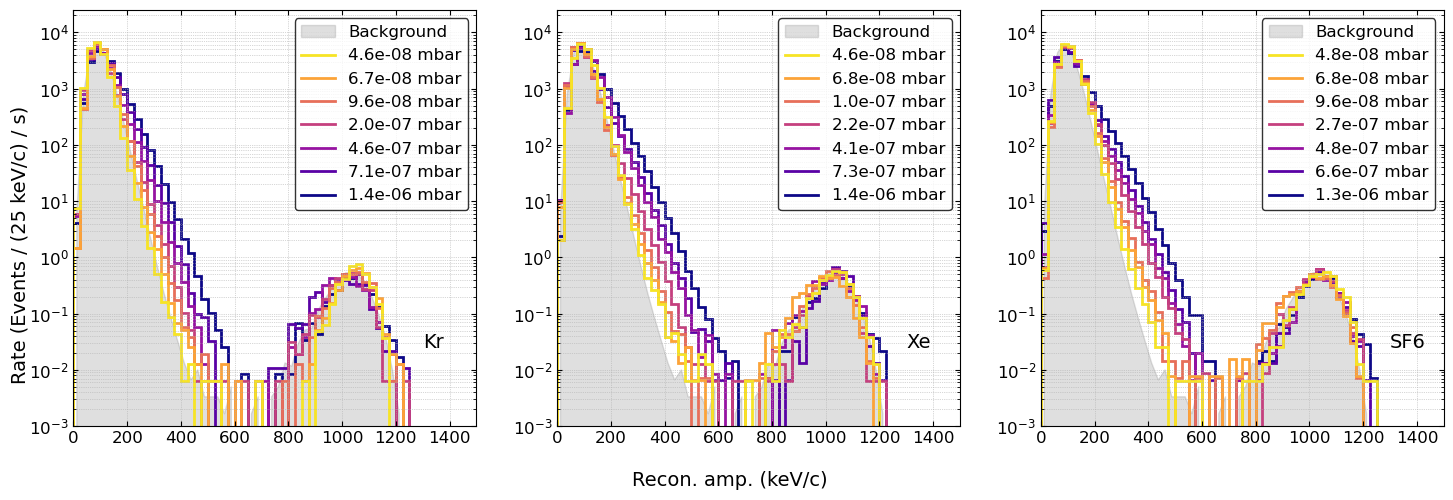

In [58]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_wcal_avg/(time_per_search*np.sum(hh_bg_wcal_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, hh_cal, p_mbar) in zip(colors, hhs[gas]):
        norm = time_per_search * np.sum(hh)
        ax.stairs(hh / norm, edges=bins, color=c, linewidth=2, label=f'{p_mbar:.1e} mbar')

    ax.text(1300, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(1e-3, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1] + handles[1:][::-1], labels[:1] + labels[1:][::-1], edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()

## Cal-pulse-removed spectra

Same three-panel layout zoomed to 0–850 keV/c, using cal-pulse-removed histograms (`hh_nocal`). Applied calibration impulses are identified by timing coincidence with the trigger and amplitude > 700 keV/c, and excluded from both the signal and background. The background shading uses the cal-removed average (`hh_bg_avg`). This is the primary view for assessing the gas collision signal: excess counts above the background are from actual gas molecule recoils.

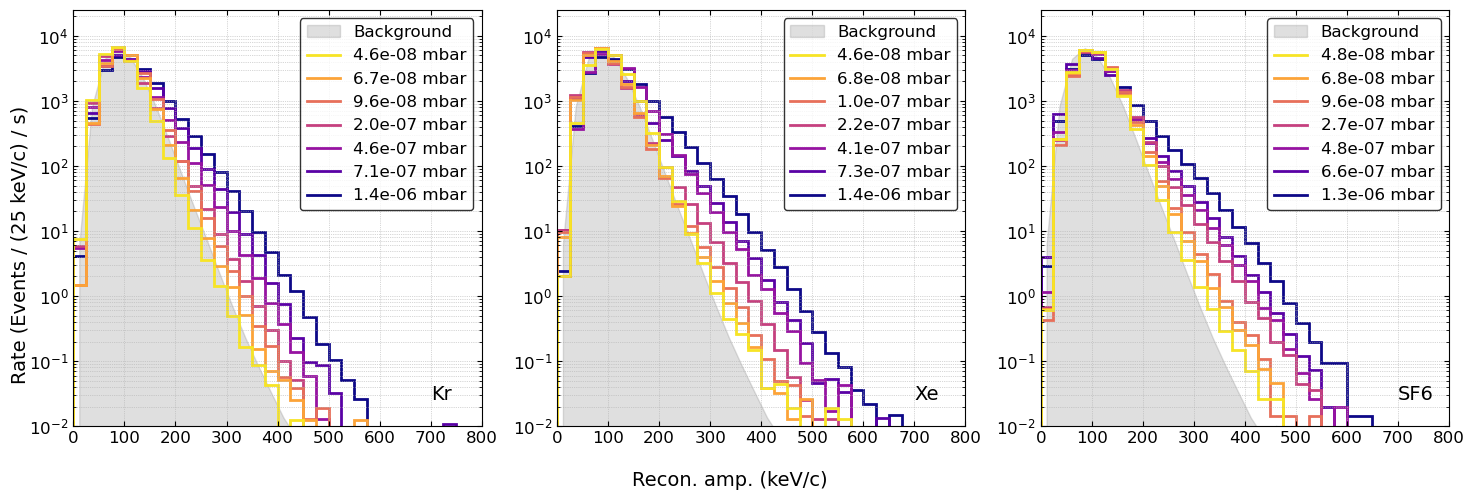

In [59]:
colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_avg/(time_per_search*np.sum(hh_bg_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, hh_cal, p_mbar) in zip(colors, hhs[gas]):
        norm = time_per_search * np.sum(hh_nocal)
        ax.stairs(hh_nocal / norm, edges=bins, color=c, linewidth=2, linestyle='-', label=f'{p_mbar:.1e} mbar')

    ax.text(700, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 800)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1] + handles[1:][::-1], labels[:1] + labels[1:][::-1], edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.tight_layout()

## Cal-pulse-removed spectra without chi2 cut

Same three-panel layout as the primary cal-pulse-removed spectra, but using `_drive_nocal` histograms — after homodyne balance, noise, and drive power cuts but **before** the chi2 cut and double-count removal. Useful for assessing how much the chi2 cut changes the spectra.

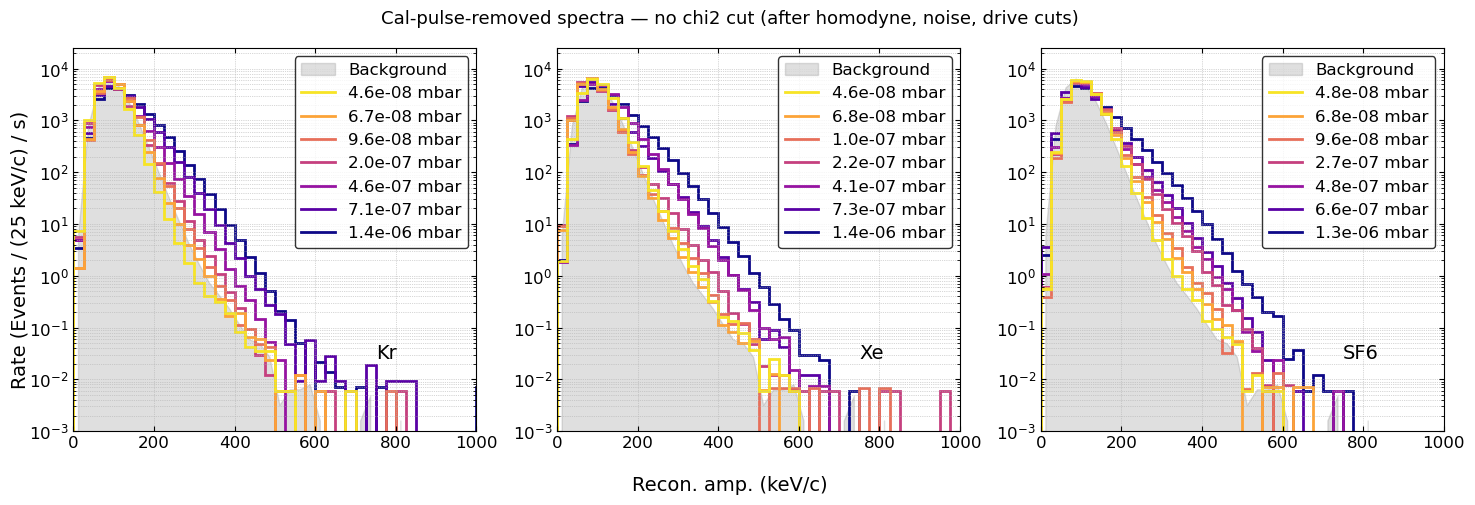

In [41]:
with h5py.File(recon_file, 'r') as f:
    # Load _drive_nocal (pre-chi2) histograms for all gas types and datasets
    hhs_drive = {}
    for gas in gas_types:
        grp = f['recon_histograms'][gas]
        datasets = [k for k in grp if not any(k.endswith(s) for s in _stage_suffixes)]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        datasets.sort(key=lambda d: grp[d].attrs['pressure_mbar'], reverse=True)
        hhs_drive[gas] = [
            (grp[d + '_drive_nocal'][:], grp[d].attrs['pressure_mbar'])
            for d in datasets
        ]

hhs_bg_drive = np.asarray([hhs_drive['background'][i][0] for i in range(4)])
hh_bg_drive_avg = np.mean(hhs_bg_drive, axis=0)

colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_drive_avg / (time_per_search * np.sum(hh_bg_drive_avg)),
                    color='gray', alpha=0.25, label='Background')

    for c, (hh_drive, p_mbar) in zip(colors, hhs_drive[gas]):
        norm = time_per_search * np.sum(hh_drive)
        ax.stairs(hh_drive / norm, edges=bins, color=c, linewidth=2, label=f'{p_mbar:.1e} mbar')

    ax.text(750, 2.5e-2, label, fontsize=14)
    ax.set_yscale('log')
    ax.set_xlim(0, 1000)
    ax.set_ylim(1e-3, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1] + handles[1:][::-1], labels[:1] + labels[1:][::-1], edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Rate (Events / (25 keV/c) / s)', fontsize=14)
fig.suptitle('Cal-pulse-removed spectra — no chi2 cut (after homodyne, noise, drive cuts)', fontsize=13)
fig.tight_layout()

## Calibration pulses only

Same layout showing only the flagged calibration pulses (`hh_cal`). The cal-pulse peak at ~1100 keV/c should be consistent across all pressures and gas species, serving as an in-situ monitor of reconstruction stability throughout the measurement campaign.

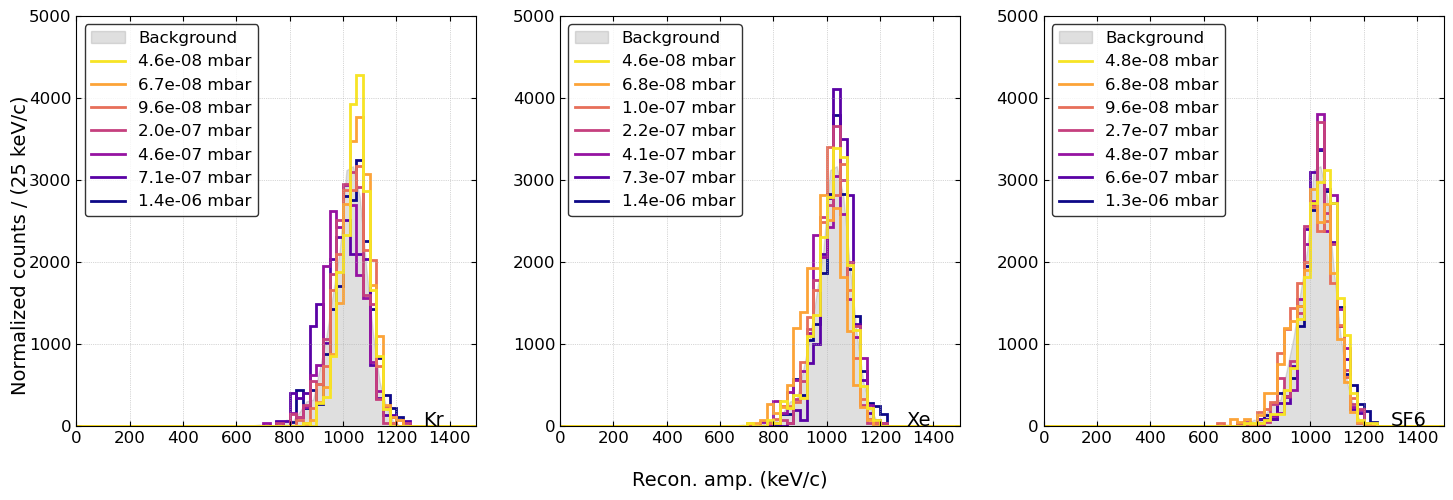

In [42]:
hhs_bg_cal = np.asarray([hhs['background'][i][2] for i in range(4)])
hh_bg_cal_avg = np.mean(hhs_bg_cal, axis=0)

colors = plt.colormaps['plasma'](np.linspace(0, 0.95, 7))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, gas, label in zip(axes, ['krypton', 'xenon', 'sf6'], ['Kr', 'Xe', 'SF6']):
    ax.fill_between(bc, 0, hh_bg_cal_avg/(time_per_search*np.sum(hh_bg_cal_avg)), color='gray', alpha=0.25, label='Background')

    for c, (hh, hh_nocal, hh_cal, p_mbar) in zip(colors, hhs[gas]):
        if np.sum(hh_cal) == 0:
            continue
        norm = time_per_search * np.sum(hh_cal)
        ax.stairs(hh_cal/norm, edges=bins, color=c, linewidth=2, label=f'{p_mbar:.1e} mbar')

    ax.text(1300, 2.5e-2, label, fontsize=14)
    # ax.set_yscale('log')
    ax.set_xlim(0, 1500)
    ax.set_ylim(0, 5000)
    ax.grid(which='both', ls=':', linewidth=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:1] + handles[1:][::-1], labels[:1] + labels[1:][::-1], edgecolor='k')

fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
fig.supylabel('Normalized counts / (25 keV/c)', fontsize=14)
fig.tight_layout()

## Species comparison at matched pressures

Each panel overlays Kr (red), Xe (green), and SF6 (blue) at approximately the same pressure level, from highest (top-left) to lowest (bottom-right). This highlights how the recoil spectrum shape differs between species at a given collision rate: heavier molecules (SF6, 146 u) transfer more momentum per collision and produce a softer spectrum shifted to higher amplitudes compared to lighter species (Kr, 84 u; Xe, 131 u). Panels where a species has no corresponding pressure are skipped. All spectra are cal-pulse-removed (`hh_nocal`) and normalised to rate.

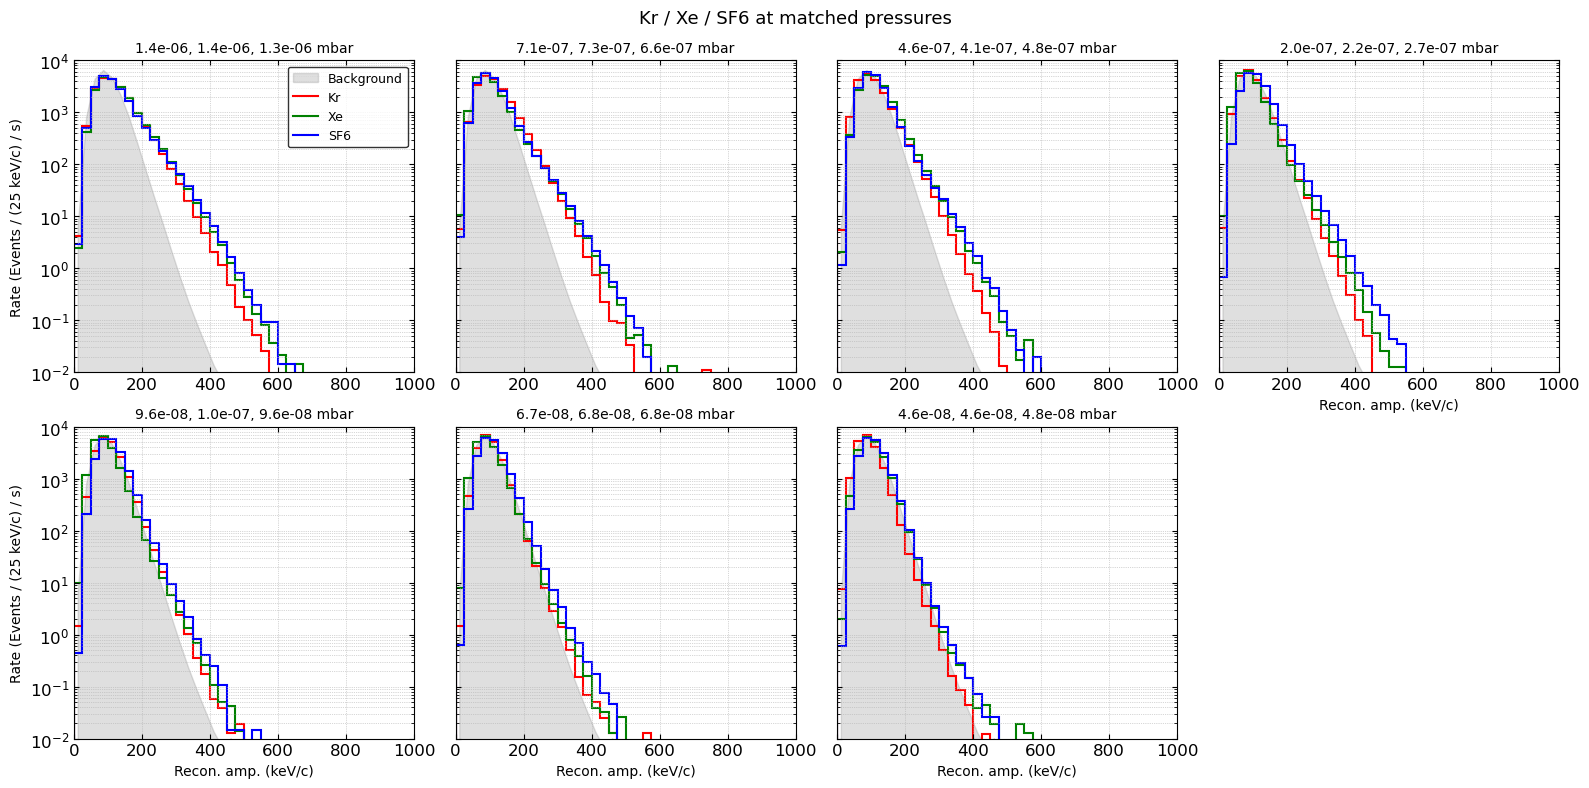

In [43]:
gas_styles = [
    ('krypton', 'Kr',  'r'),
    ('xenon',   'Xe',  'g'),
    ('sf6',     'SF6', 'b'),
]

n_pressures = max(len(hhs[gas]) for gas, _, _ in gas_styles)
ncols = 4
nrows = (n_pressures + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), sharey=True)
axes_flat = axes.flat

bg_norm = time_per_search * np.sum(hh_bg_avg)

for i in range(n_pressures):
    ax = axes_flat[i]
    ax.fill_between(bc, 0, hh_bg_avg / bg_norm, color='gray', alpha=0.25, label='Background')

    p_labels = []
    for gas, label, color in gas_styles:
        if i >= len(hhs[gas]):
            continue
        hh, hh_nocal, hh_cal, p_mbar = hhs[gas][i]
        norm = time_per_search * np.sum(hh_nocal)
        ax.stairs(hh_nocal / norm, edges=bins, color=color, linewidth=1.5, label=label)
        p_labels.append(f'{p_mbar:.1e}')

    ax.set_title(', '.join(p_labels) + ' mbar', fontsize=10)
    ax.set_yscale('log')
    ax.set_xlim(0, 1000)
    ax.set_ylim(1e-2, 1e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    if i % ncols == 0:
        ax.set_ylabel('Rate (Events / (25 keV/c) / s)', fontsize=10)
    if i >= n_pressures - ncols:
        ax.set_xlabel('Recon. amp. (keV/c)', fontsize=10)

# Legend on first panel; hide unused panels
axes_flat[0].legend(edgecolor='k', fontsize=9)
for ax in list(axes_flat)[n_pressures:]:
    ax.set_visible(False)

fig.suptitle('Kr / Xe / SF6 at matched pressures', fontsize=13)
fig.tight_layout()

## Xe 1e-6 mbar: effect of data cuts

Shows the Xe 1e-6 mbar spectrum at each cumulative selection stage (nocal variant) to visualise the effect of each successive cut. Stages: no cuts → homodyne balance → noise threshold → drive power → chi2 → double-count removal (final).

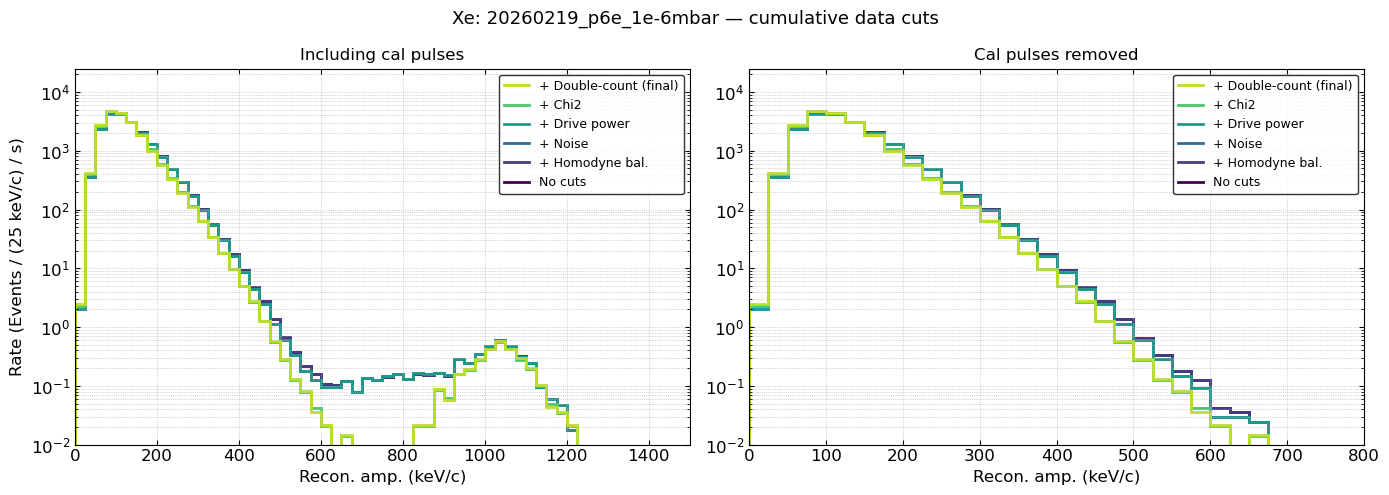

In [60]:
# Load stage-by-stage histograms for Xe 1e-6 mbar
xe_dataset = '20260219_p6e_1e-6mbar'
stages = [
    ('nocuts',  'No cuts'),
    ('hom_bal', '+ Homodyne bal.'),
    ('noise',   '+ Noise'),
    ('drive',   '+ Drive power'),
    ('chi2',    '+ Chi2'),
    ('all',     '+ Double-count (final)'),
]

with h5py.File(recon_file, 'r') as f:
    grp = f['recon_histograms']['xenon']
    xe_stages = {}
    for key, label in stages:
        if key == 'all':
            name_nocal = xe_dataset + '_nocal'
            name_total = xe_dataset
        else:
            name_nocal = f'{xe_dataset}_{key}_nocal'
            name_total = f'{xe_dataset}_{key}'
        xe_stages[key] = {
            'nocal': grp[name_nocal][:],
            'total': grp[name_total][:],
            'label': label,
        }

# Plot
colors_stage = plt.colormaps['viridis'](np.linspace(0, 0.9, len(stages)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, variant, title in zip(axes, ['total', 'nocal'], ['Including cal pulses', 'Cal pulses removed']):
    for c, (key, label) in zip(colors_stage, stages):
        h = xe_stages[key][variant]
        norm = time_per_search * np.sum(h)
        ax.stairs(h / norm, edges=bins, color=c, linewidth=2, label=label)

    ax.set_title(title, fontsize=12)
    ax.set_yscale('log')

    if title == 'Cal pulses removed':
        ax.set_xlim(0, 800)
    else:
        ax.set_xlim(0, 1500)
    ax.set_ylim(1e-2, 2.5e4)
    ax.grid(which='both', ls=':', linewidth=0.5)
    ax.set_xlabel('Recon. amp. (keV/c)', fontsize=12)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], edgecolor='k', fontsize=9)

axes[0].set_ylabel('Rate (Events / (25 keV/c) / s)', fontsize=12)
fig.suptitle(f'Xe: {xe_dataset} — cumulative data cuts', fontsize=13)
fig.tight_layout()

## Events removed by each cut — all gas datasets

Each curve shows the events **removed** by a single cut stage (cal-pulse-removed variant), for all gas species and pressures. One figure per gas type, 2×4 grid ordered high → low pressure.

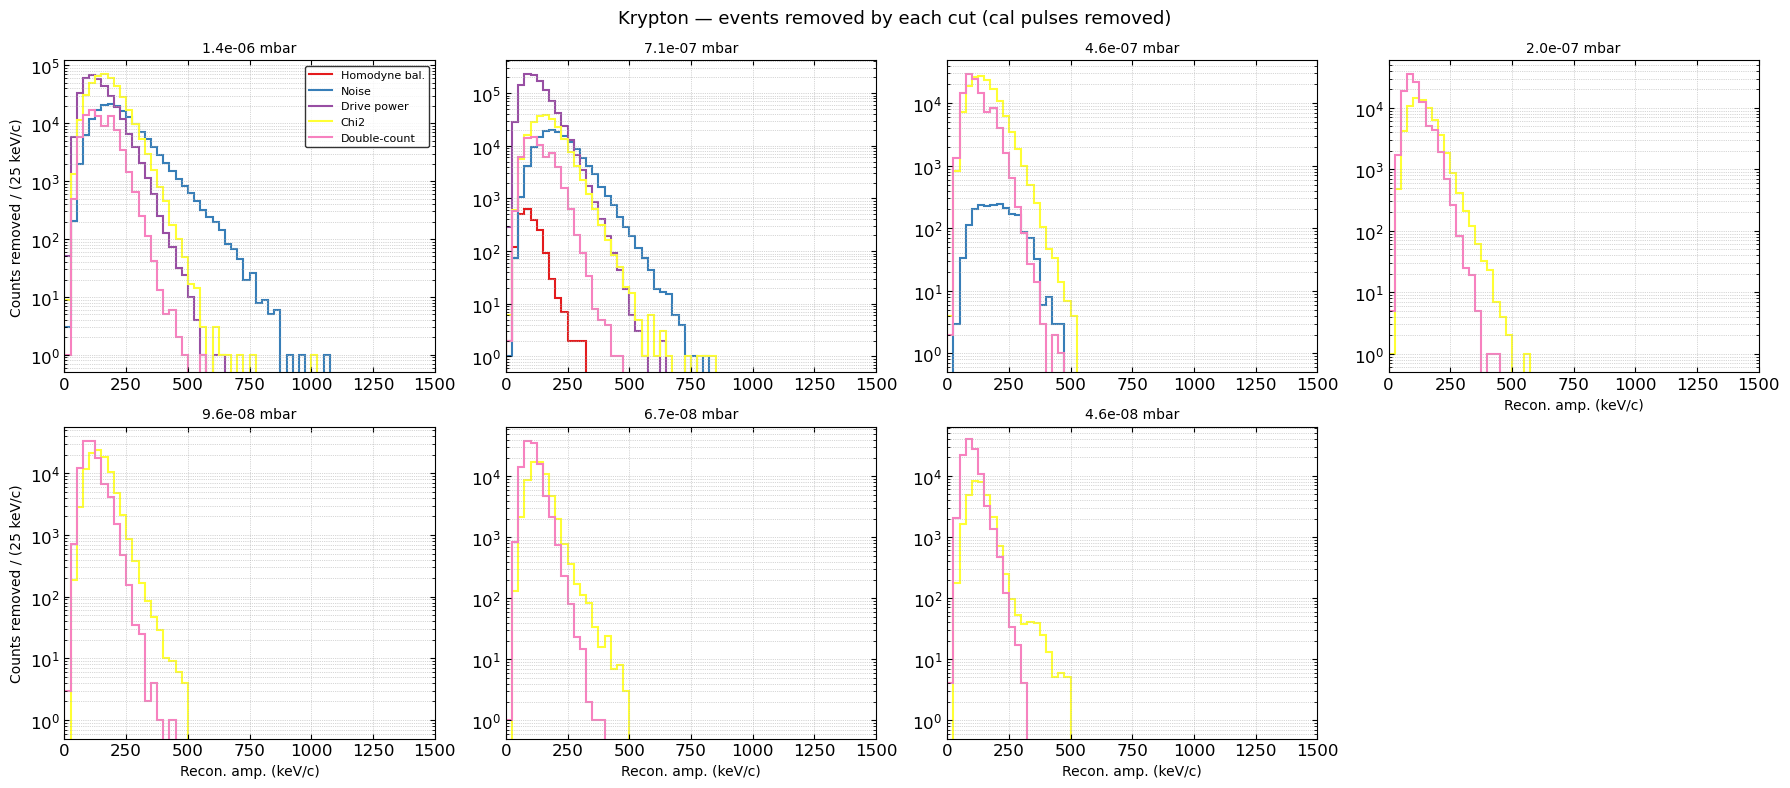

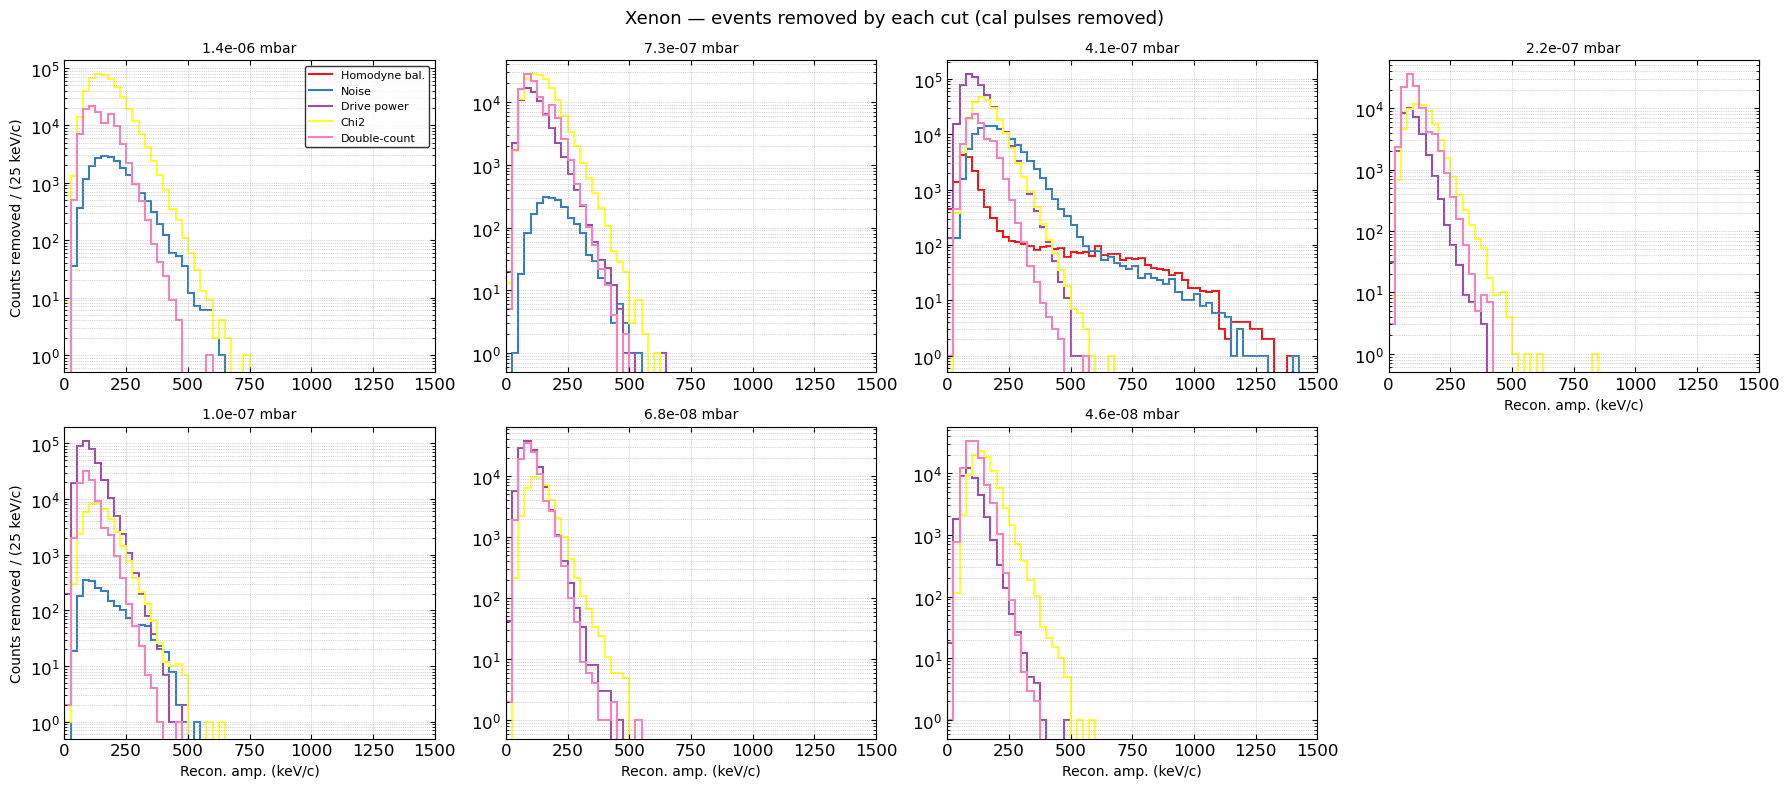

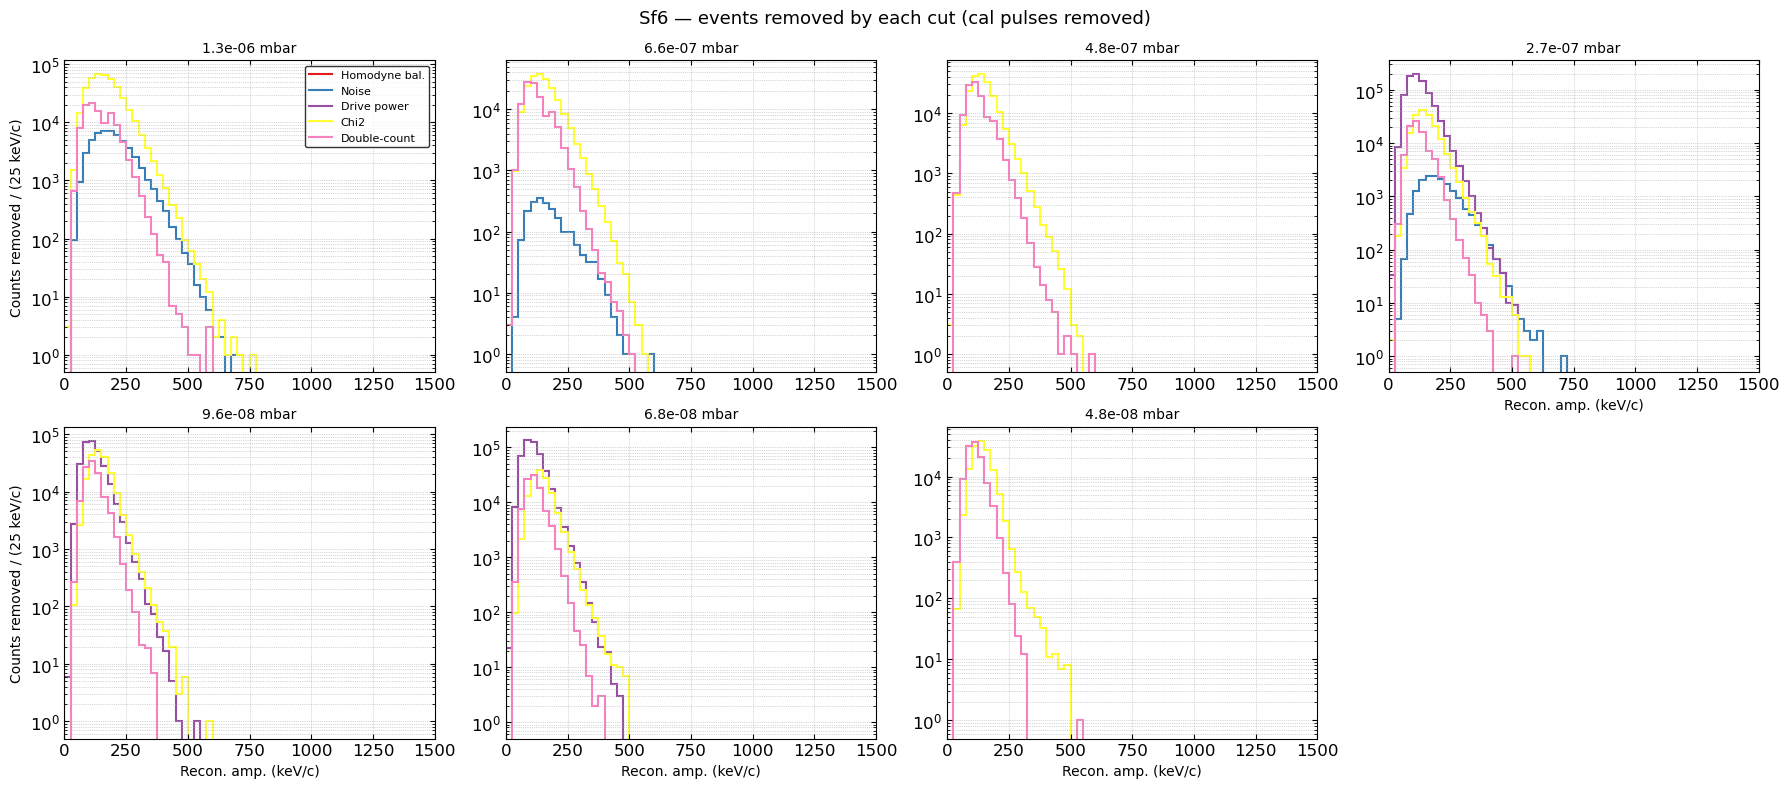

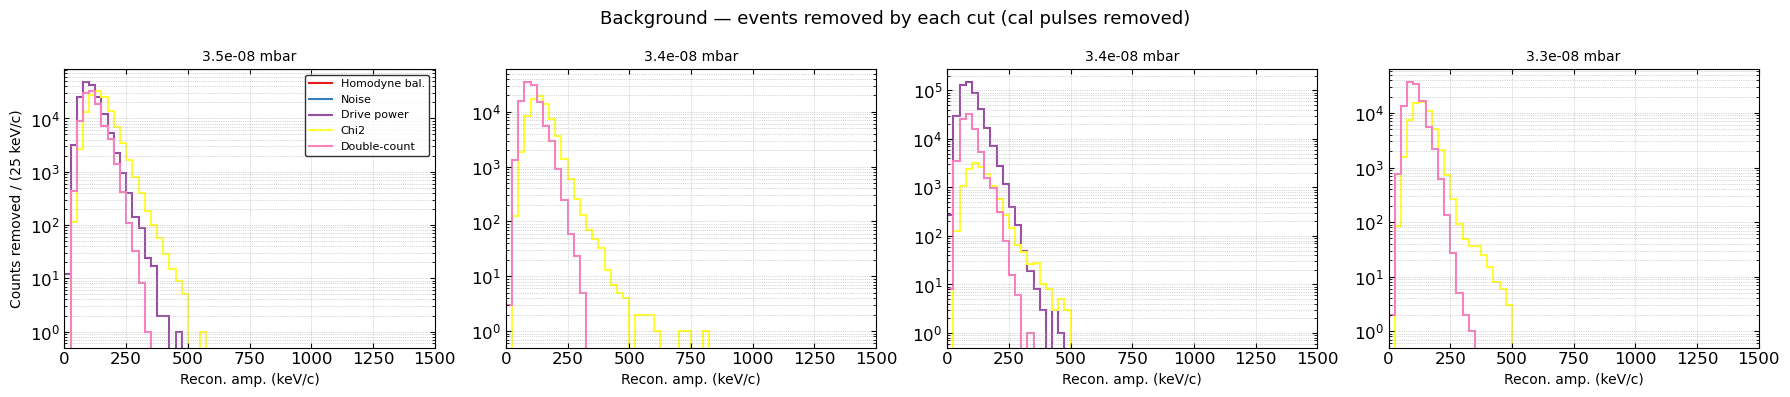

In [45]:
cut_diffs = [
    ('nocuts',  'hom_bal', 'Homodyne bal.'),
    ('hom_bal', 'noise',   'Noise'),
    ('noise',   'drive',   'Drive power'),
    ('drive',   'chi2',    'Chi2'),
    ('chi2',    'all',     'Double-count'),
]
colors_diff = plt.colormaps['Set1'](np.linspace(0, 0.8, len(cut_diffs)))

stages_to_load = ['nocuts', 'hom_bal', 'noise', 'drive', 'chi2', 'all']

for gas in ['krypton', 'xenon', 'sf6', 'background']:
    with h5py.File(recon_file, 'r') as f:
        grp = f['recon_histograms'][gas]
        datasets = [k for k in grp if not any(k.endswith(s) for s in _stage_suffixes)]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        pressures = {d: grp[d].attrs['pressure_mbar'] for d in datasets}

        gas_stages = {}
        for ds in datasets:
            ds_stages = {}
            for key in stages_to_load:
                name = ds + '_nocal' if key == 'all' else f'{ds}_{key}_nocal'
                ds_stages[key] = grp[name][:]
            gas_stages[ds] = ds_stages

    datasets.sort(key=lambda d: pressures[d], reverse=True)

    ncols = 4
    nrows = max(1, (len(datasets) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
    axes_flat = np.atleast_1d(axes).flat

    for idx, ds in enumerate(datasets):
        ax = axes_flat[idx]
        for c, (before, after, label) in zip(colors_diff, cut_diffs):
            removed = gas_stages[ds][before] - gas_stages[ds][after]
            ax.stairs(removed, edges=bins, color=c, linewidth=1.5, label=label)
        ax.set_title(f'{pressures[ds]:.1e} mbar', fontsize=10)
        ax.set_yscale('log')
        ax.set_xlim(0, 1500)
        ax.set_ylim(0.5, None)
        ax.grid(which='both', ls=':', linewidth=0.5)
        if idx >= len(datasets) - ncols:
            ax.set_xlabel('Recon. amp. (keV/c)', fontsize=10)
        if idx % ncols == 0:
            ax.set_ylabel('Counts removed / (25 keV/c)', fontsize=10)

    axes_flat[0].legend(edgecolor='k', fontsize=8)
    for ax in list(axes_flat)[len(datasets):]:
        ax.set_visible(False)

    fig.suptitle(f'{gas.capitalize()} — events removed by each cut (cal pulses removed)', fontsize=13)
    fig.tight_layout()

## Rejection fraction per bin by cut stage — all gas datasets

Shows the percentage of events rejected by each successive cut in each amplitude bin (cal-pulse-removed variant), for all gas species and pressures. One figure per gas type, 2×4 grid ordered high → low pressure.

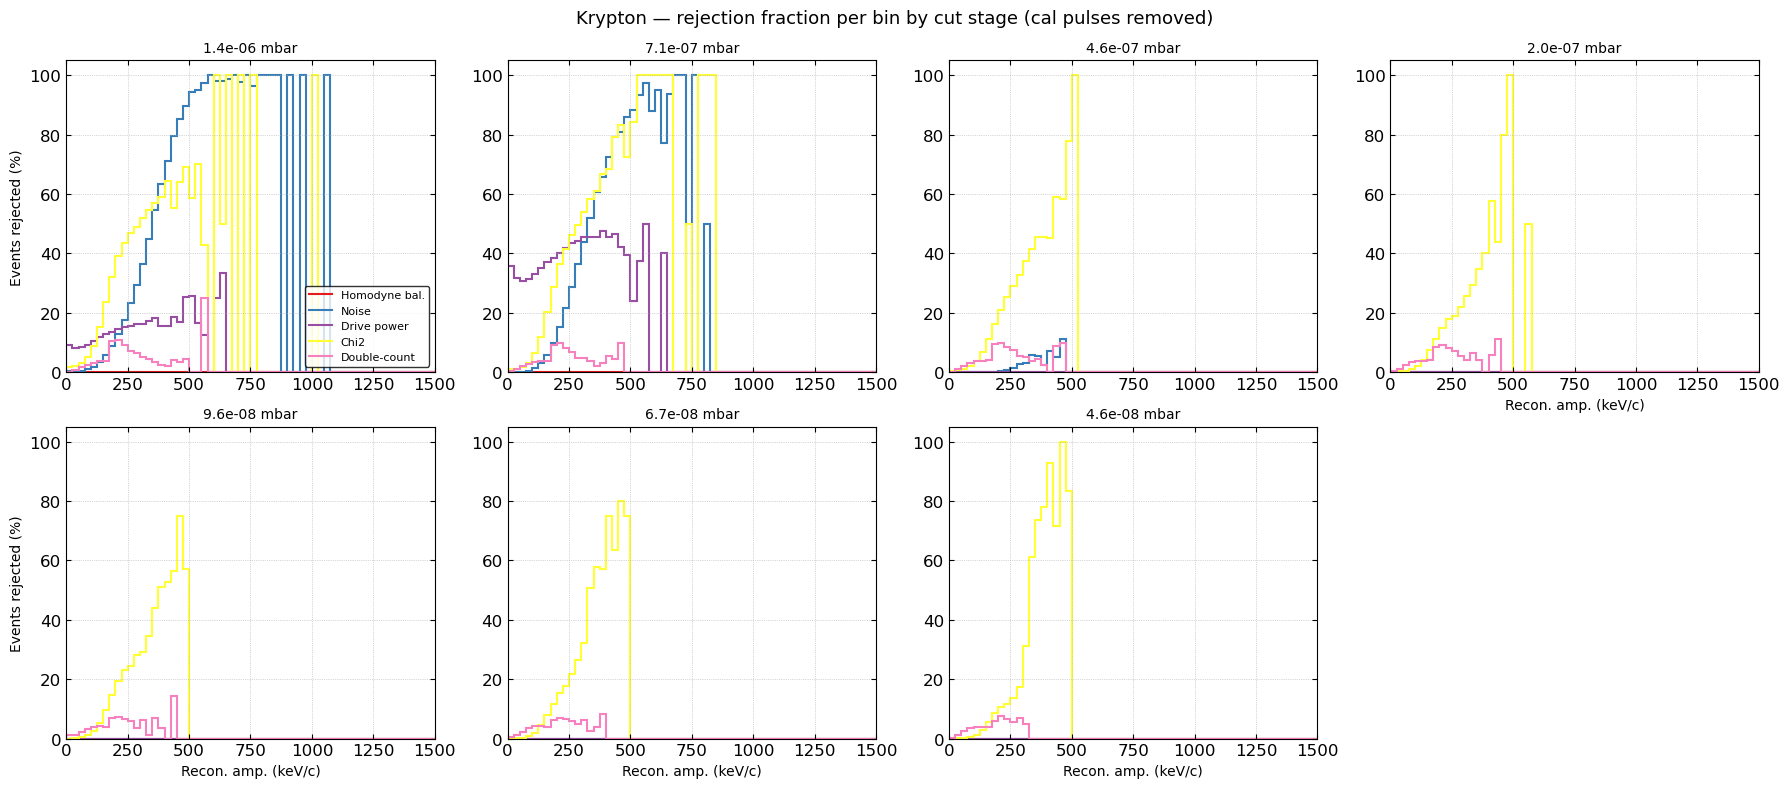

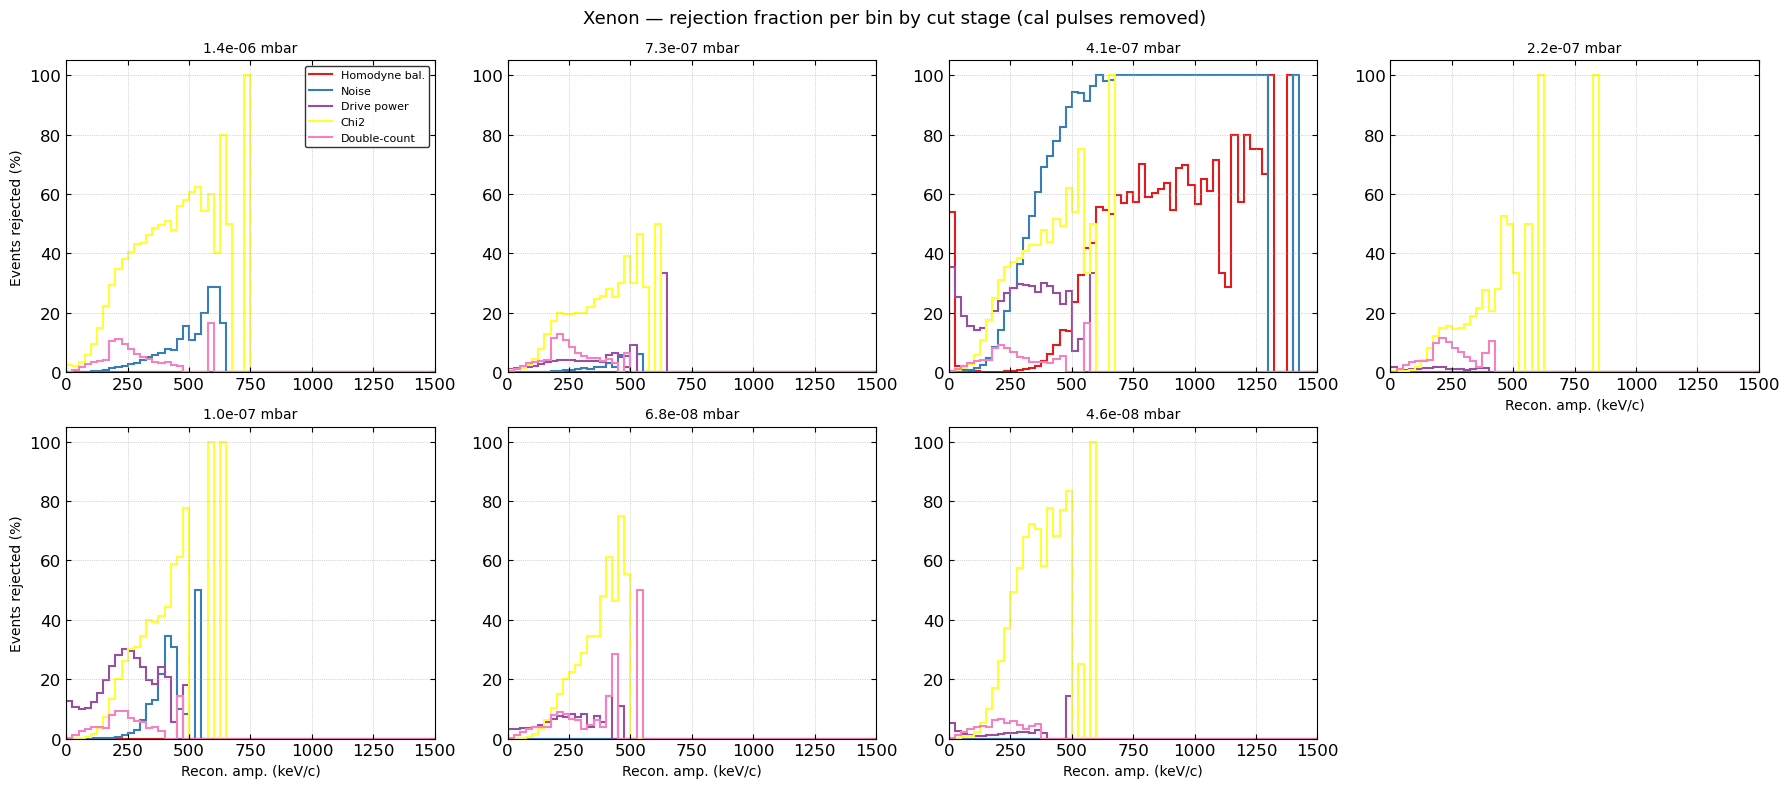

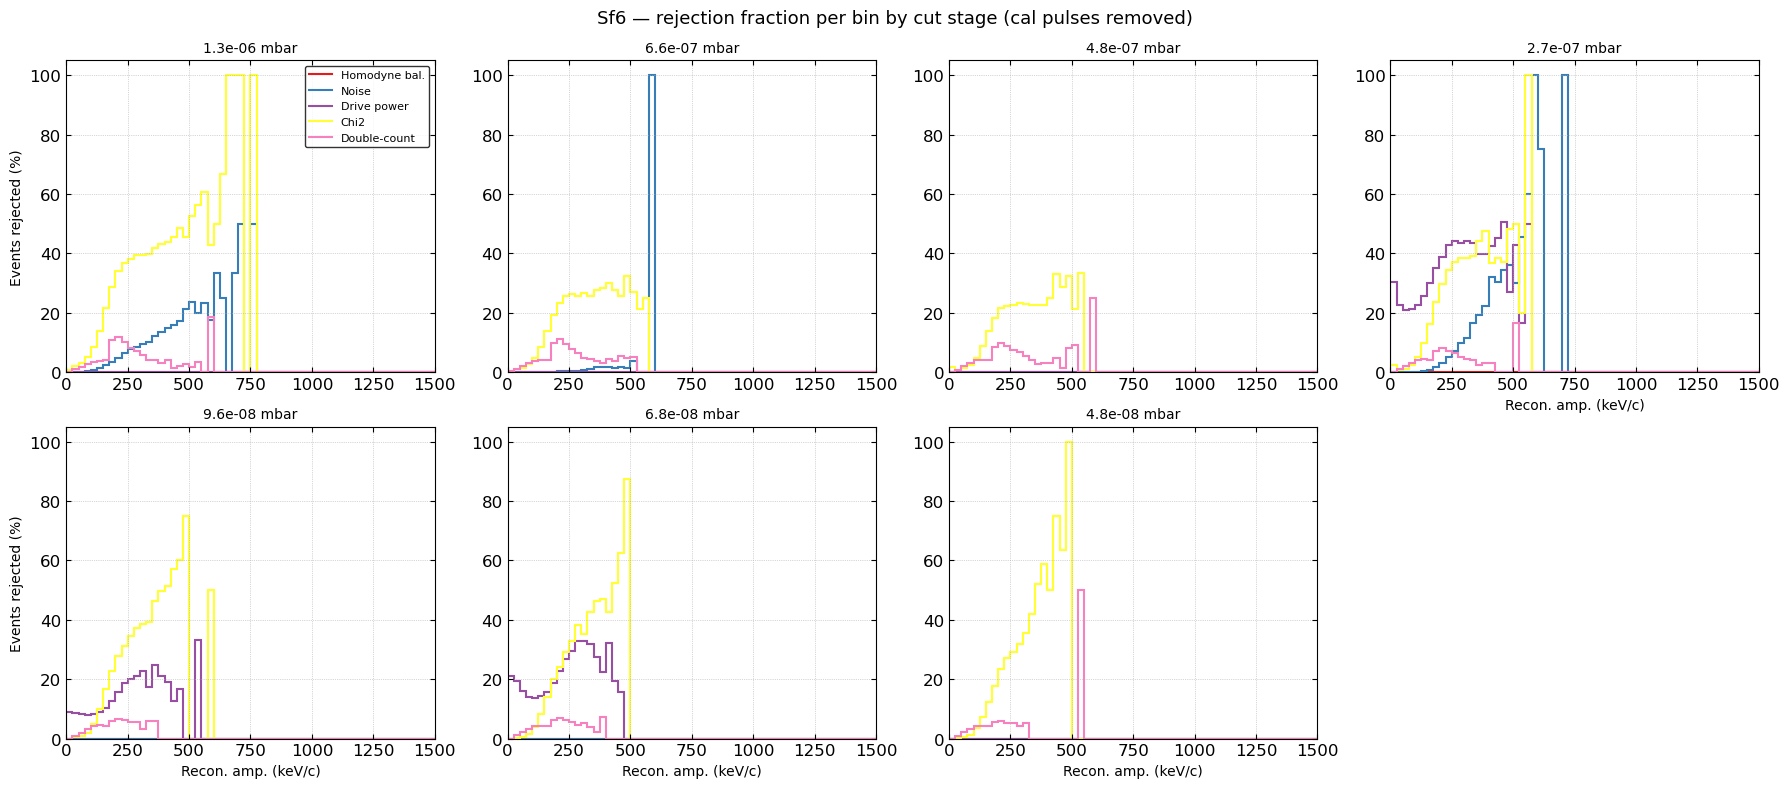

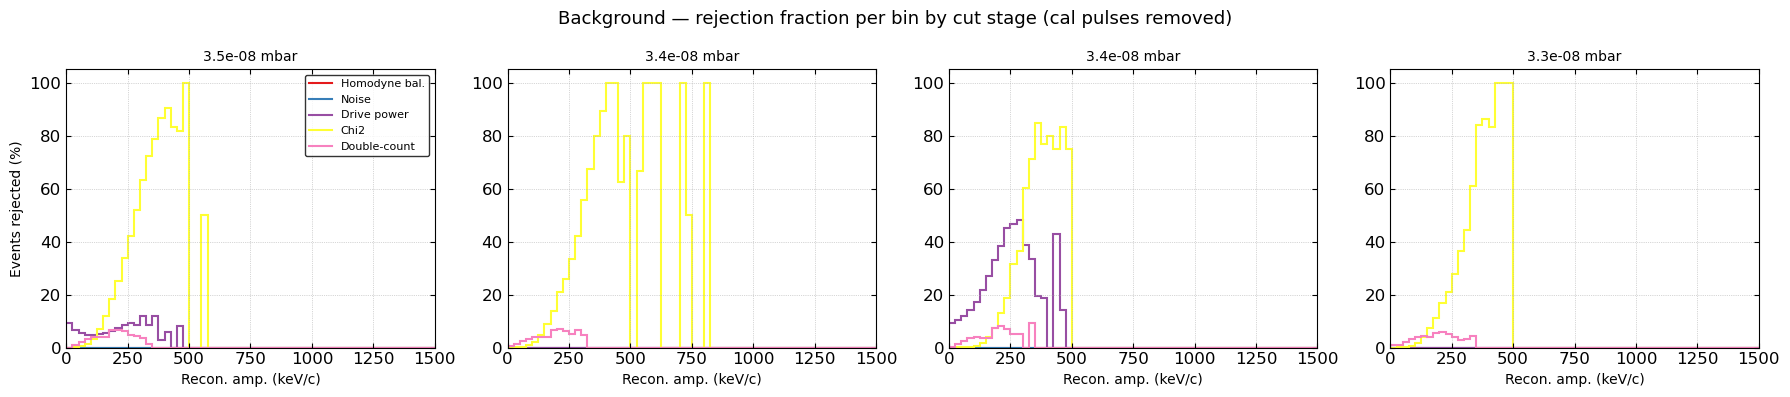

In [46]:
for gas in ['krypton', 'xenon', 'sf6', 'background']:
    with h5py.File(recon_file, 'r') as f:
        grp = f['recon_histograms'][gas]
        datasets = [k for k in grp if not any(k.endswith(s) for s in _stage_suffixes)]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        pressures = {d: grp[d].attrs['pressure_mbar'] for d in datasets}

        gas_stages = {}
        for ds in datasets:
            ds_stages = {}
            for key in stages_to_load:
                name = ds + '_nocal' if key == 'all' else f'{ds}_{key}_nocal'
                ds_stages[key] = grp[name][:]
            gas_stages[ds] = ds_stages

    datasets.sort(key=lambda d: pressures[d], reverse=True)

    ncols = 4
    nrows = max(1, (len(datasets) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
    axes_flat = np.atleast_1d(axes).flat

    for idx, ds in enumerate(datasets):
        ax = axes_flat[idx]
        for c, (before, after, label) in zip(colors_diff, cut_diffs):
            h_before = gas_stages[ds][before].astype(float)
            h_after = gas_stages[ds][after].astype(float)
            removed = h_before - h_after
            with np.errstate(divide='ignore', invalid='ignore'):
                pct = np.where(h_before > 0, 100.0 * removed / h_before, 0.0)
            ax.stairs(pct, edges=bins, color=c, linewidth=1.5, label=label)
        ax.set_title(f'{pressures[ds]:.1e} mbar', fontsize=10)
        ax.set_xlim(0, 1500)
        ax.set_ylim(0, 105)
        ax.grid(which='both', ls=':', linewidth=0.5)
        if idx >= len(datasets) - ncols:
            ax.set_xlabel('Recon. amp. (keV/c)', fontsize=10)
        if idx % ncols == 0:
            ax.set_ylabel('Events rejected (%)', fontsize=10)

    axes_flat[0].legend(edgecolor='k', fontsize=8)
    for ax in list(axes_flat)[len(datasets):]:
        ax.set_visible(False)

    fig.suptitle(f'{gas.capitalize()} — rejection fraction per bin by cut stage (cal pulses removed)', fontsize=13)
    fig.tight_layout()

## Chi2 vs amplitude (2D histograms)

2D histograms of chi2 vs reconstructed amplitude for all datasets, after applying homodyne balance, noise threshold, and drive power cuts (i.e. all cuts preceding the chi2 cut). All search indices within passing windows are included (flattened). Amplitude is converted to keV/c using the per-file `amp2kev` attribute. One figure per gas species.

In [47]:
processed_base = r'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/gas_data_processed/sphere_20260215'
file_prefix = '20260219_dfg_'
nfiles = 25

noise_threshold_kev = 70
chi2_threshold = 600
normalized_drive_power_threshold = 4.5e-9
drive_freq = 137000
ref_freq = 48500

# Reconstruction parameters (sphere_20260215)
analysis_window_length_gas = 2**19
fs_raw                     = 5_000_000.0   # Hz
bandpass_lb_xe             = 35000
bandpass_ub_xe             = 80000
lowpass_order              = 3
gamma_damping_xe           = 1 * 2 * np.pi
c_imp_xe                   = 1.5e-22

gas_dir_map = {
    'xenon': 'xenon_data',
    'krypton': 'krypton_data',
    'sf6': 'sf6_data',
    'background': 'background_data',
}

def load_amp_chi2(gas_dir, dataset):
    """Load |amplitude| (keV/c) and chi2 after homodyne, noise, and drive cuts."""
    amps_kev, chi2s = [], []
    for i in range(nfiles):
        fpath = os.path.join(processed_base, gas_dir, dataset, f'{file_prefix}{i}_processed.hdf5')
        with h5py.File(fpath, 'r') as f:
            g = f['data_processed']
            a2k = g.attrs['amp2kev']
            good = g['good_detection'][:]
            noise = g['noise_level_amp'][:]
            driven = g['driven_power'][:]
            freq = g['f_res'][:]
            amp = g['amplitude'][:]
            chi2 = g['chisquare'][:]

        # Homodyne balance
        mask = good.copy()
        # Noise threshold
        mask &= noise * a2k < noise_threshold_kev
        # Normalized drive power
        norm_drive = driven * (freq**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        mask &= norm_drive > normalized_drive_power_threshold

        # Apply per-window mask and flatten across search indices
        amps_kev.append(np.abs(amp[mask]).flatten() * a2k)
        chi2s.append(chi2[mask].flatten())
    return np.concatenate(amps_kev), np.concatenate(chi2s)

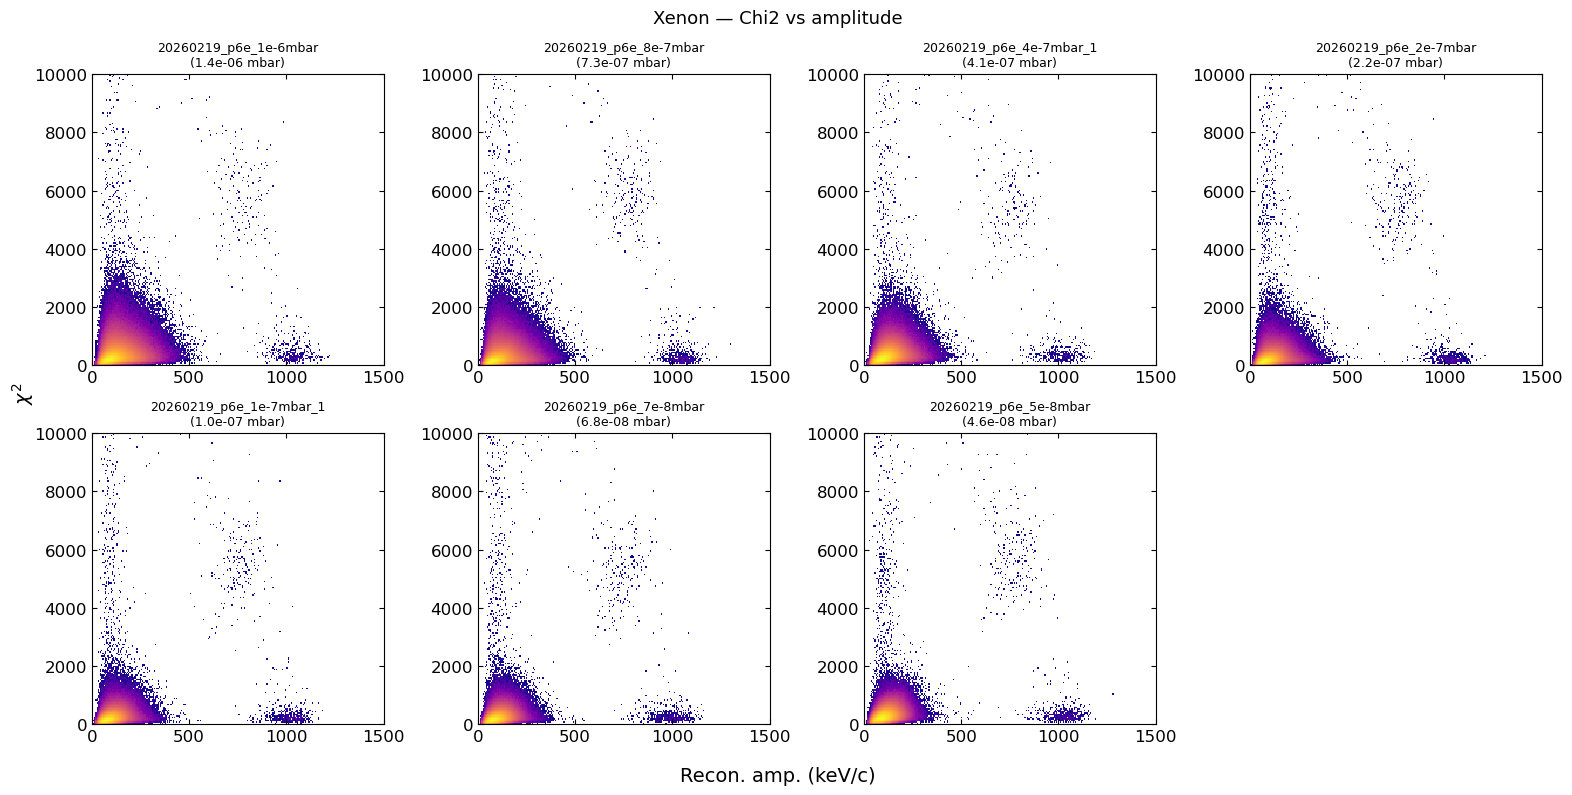

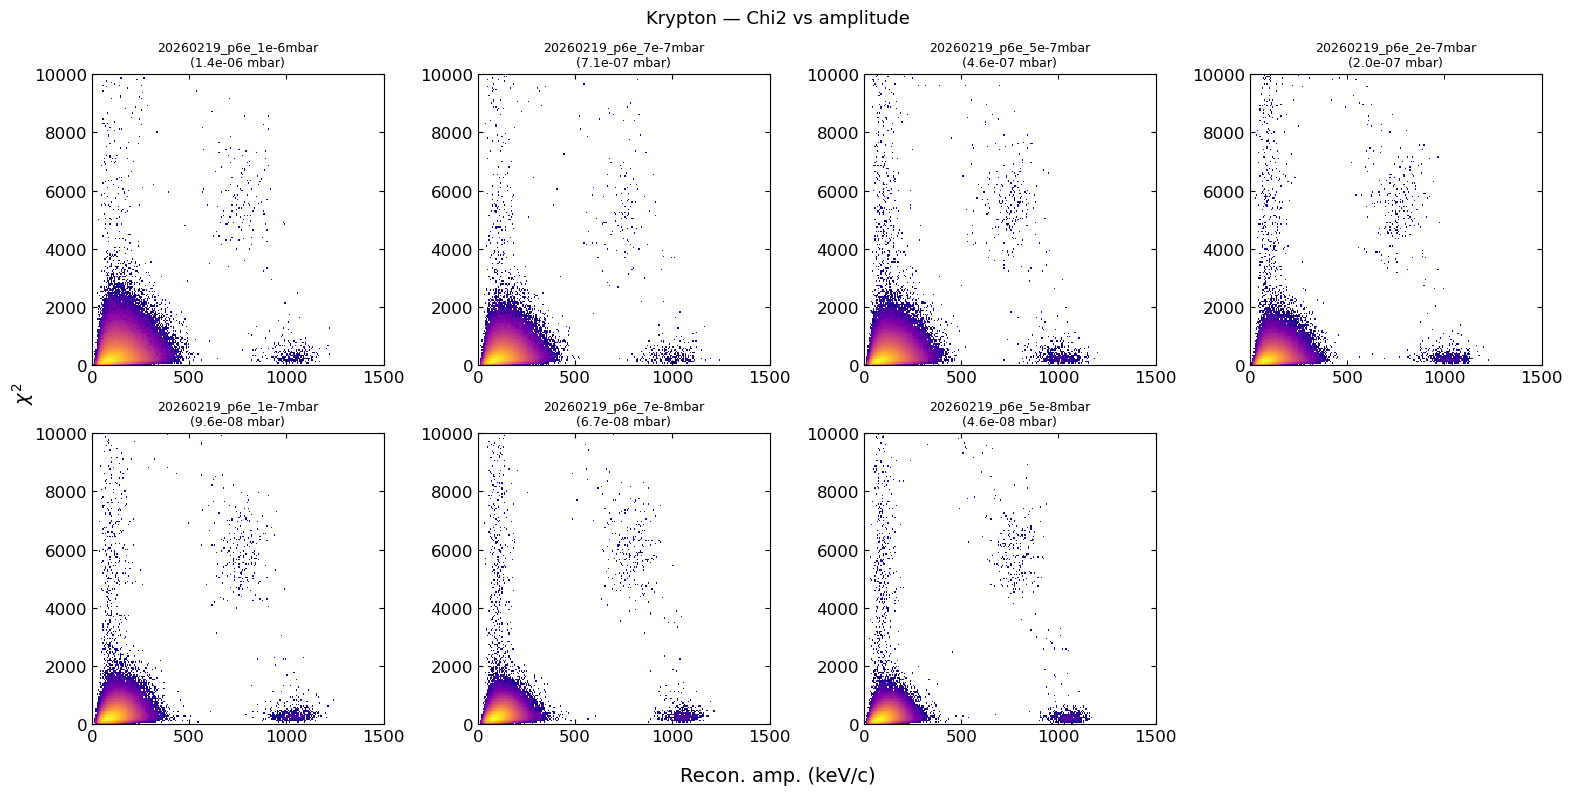

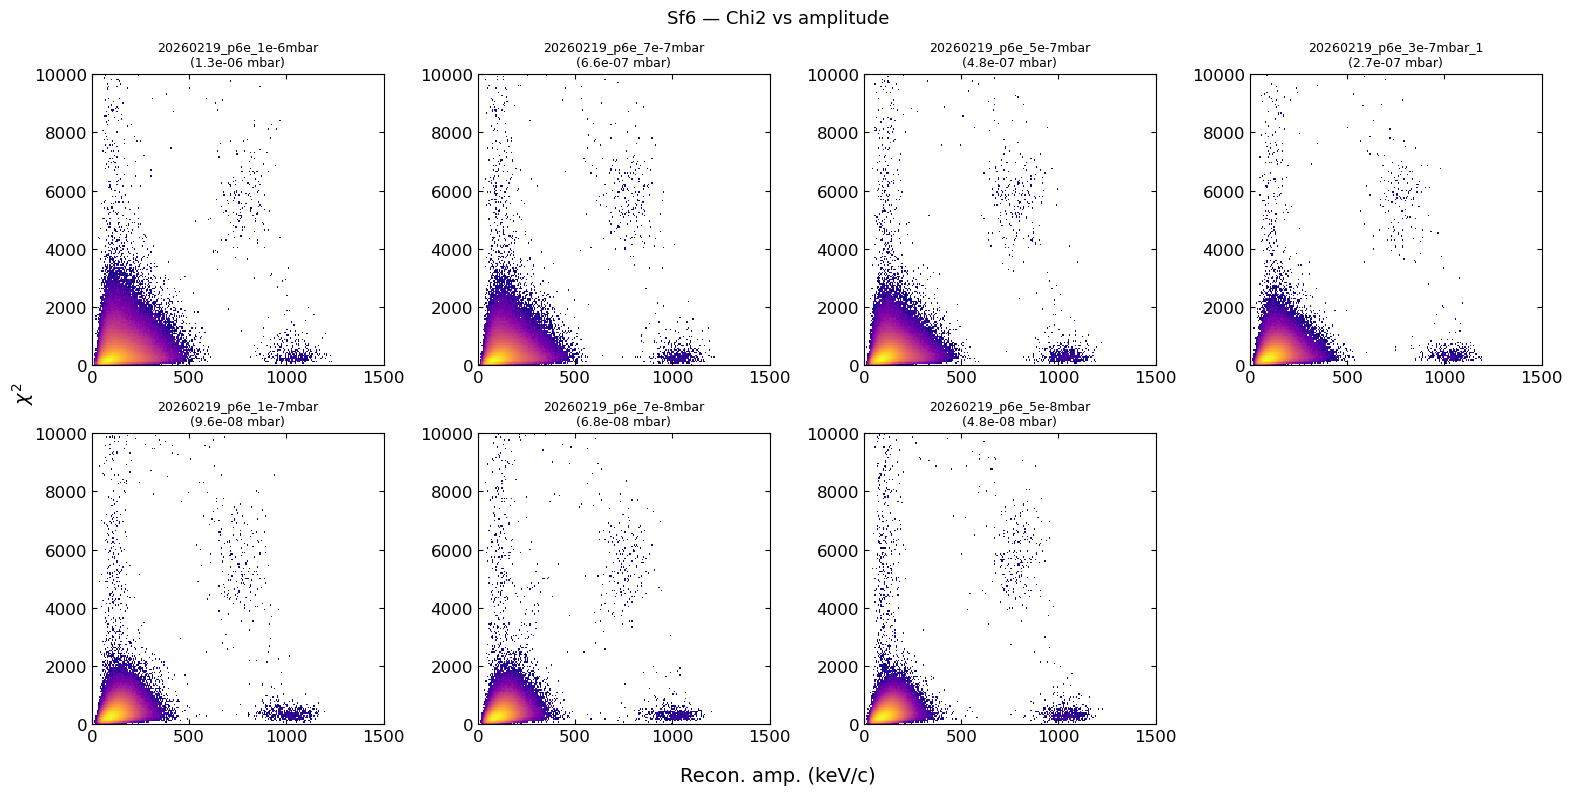

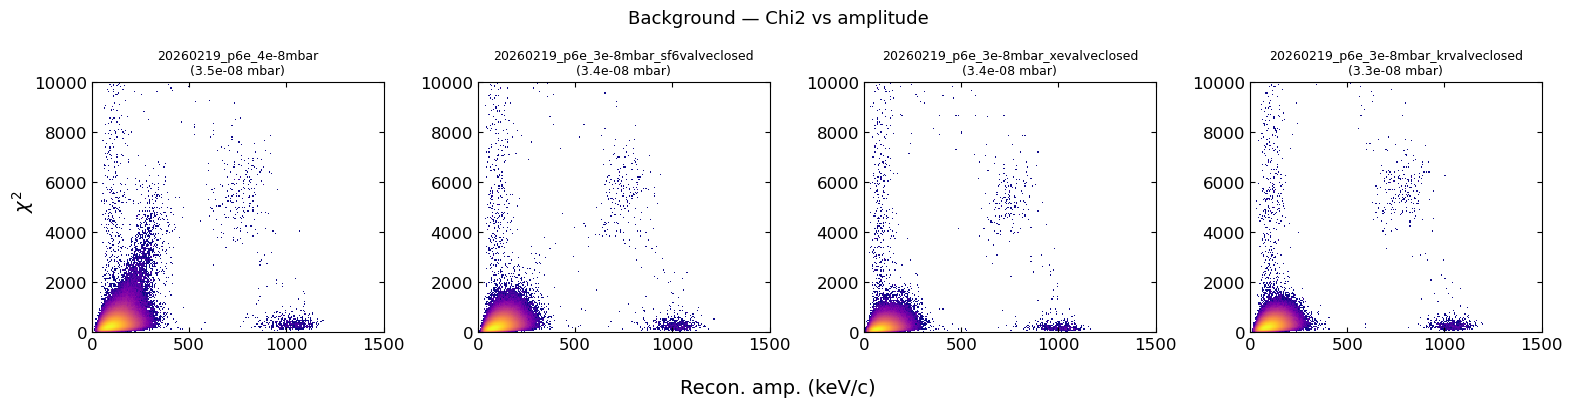

In [48]:
xbins = np.linspace(0, 1500, 250)
ybins = np.linspace(0, 10000, 200)

for gas in gas_types:
    gas_dir = gas_dir_map[gas]
    # Get dataset names from recon file (same ordering as hhs)
    with h5py.File(recon_file, 'r') as f:
        grp = f['recon_histograms'][gas]
        datasets = [k for k in grp
                    if not any(k.endswith(s) for s in _stage_suffixes)]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        pressures = {d: grp[d].attrs['pressure_mbar'] for d in datasets}
    datasets.sort(key=lambda d: pressures[d], reverse=True)

    ncols = 4
    nrows = max(1, (len(datasets) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes_flat = np.atleast_1d(axes).flat

    for idx, dataset in enumerate(datasets):
        ax = axes_flat[idx]
        amps_kev, chi2s = load_amp_chi2(gas_dir, dataset)
        hh, _, _ = np.histogram2d(x=amps_kev, y=chi2s, bins=(xbins, ybins))
        ax.pcolormesh(xbins, ybins, hh.T, norm=mcolors.LogNorm(), cmap='plasma')
        ax.set_title(f'{dataset}\n({pressures[dataset]:.1e} mbar)', fontsize=9)
        ax.set_xlim(0, 1500)
        ax.set_ylim(0, 10000)

    for ax in list(axes_flat)[len(datasets):]:
        ax.set_visible(False)

    fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
    fig.supylabel(r'$\chi^2$', fontsize=14)
    fig.suptitle(f'{gas.capitalize()} — Chi2 vs amplitude', fontsize=13)
    fig.tight_layout()

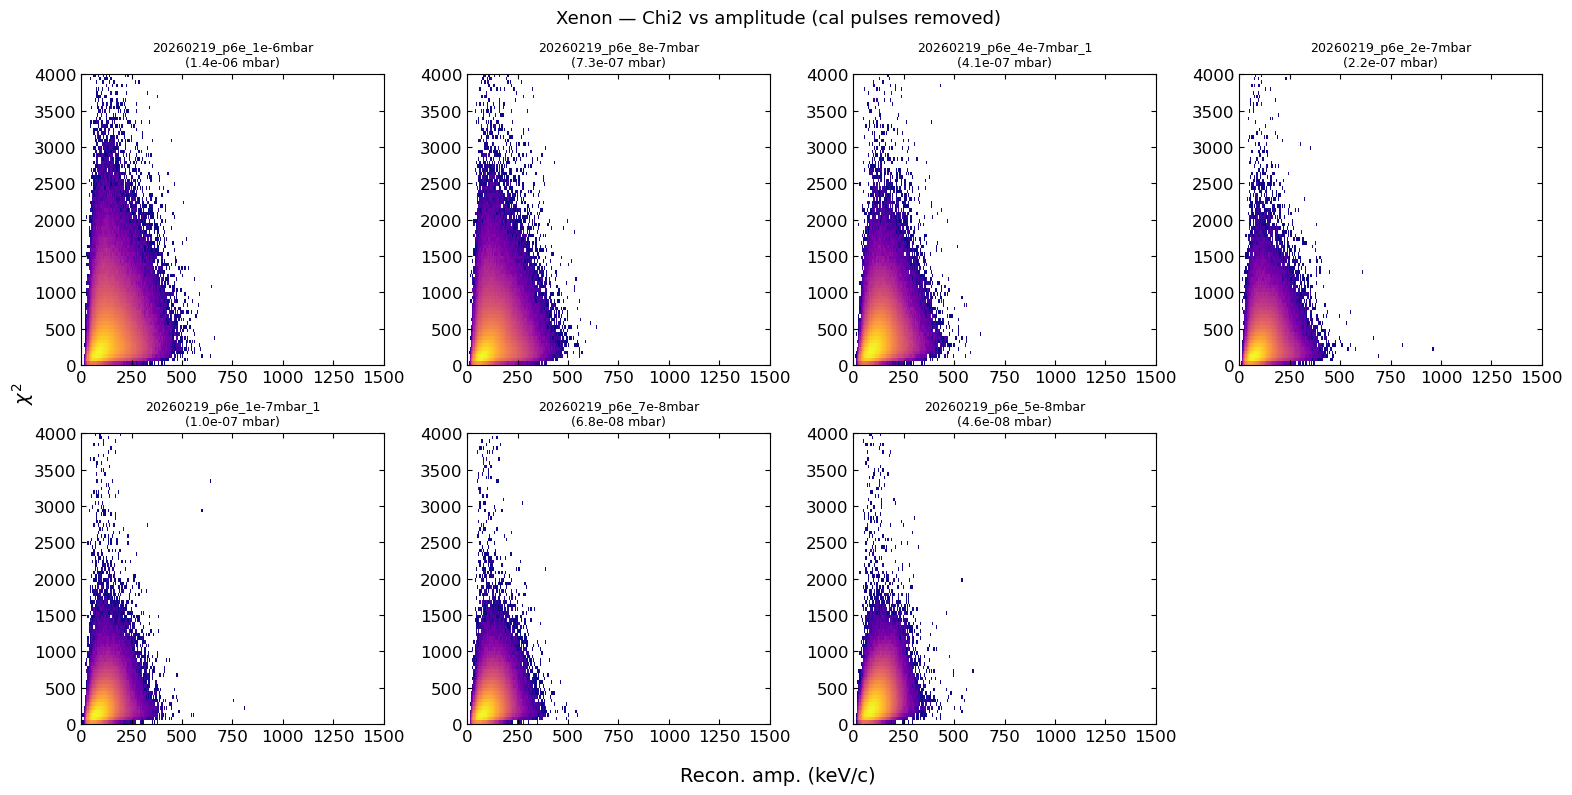

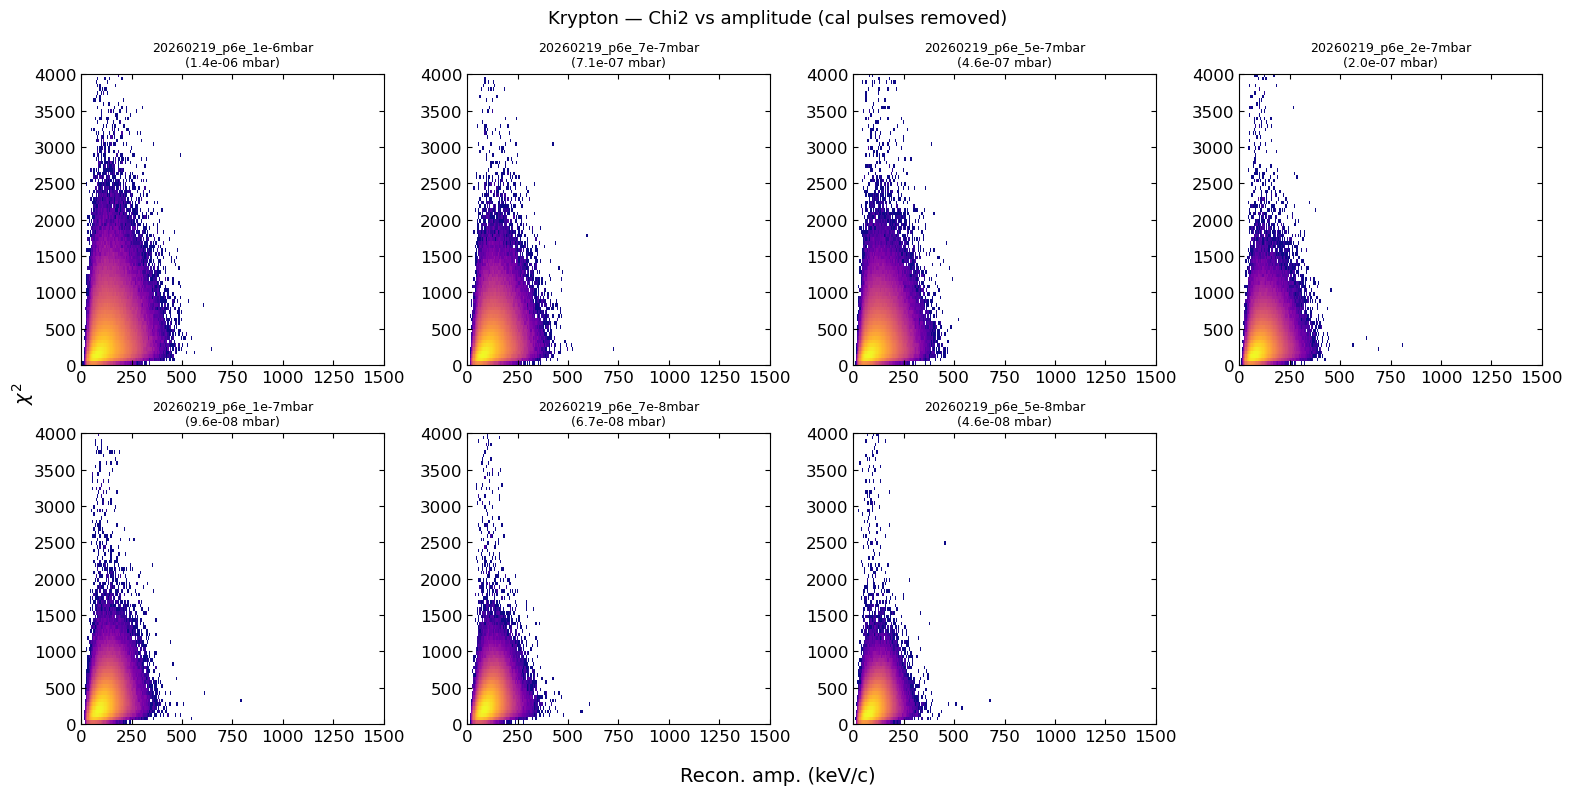

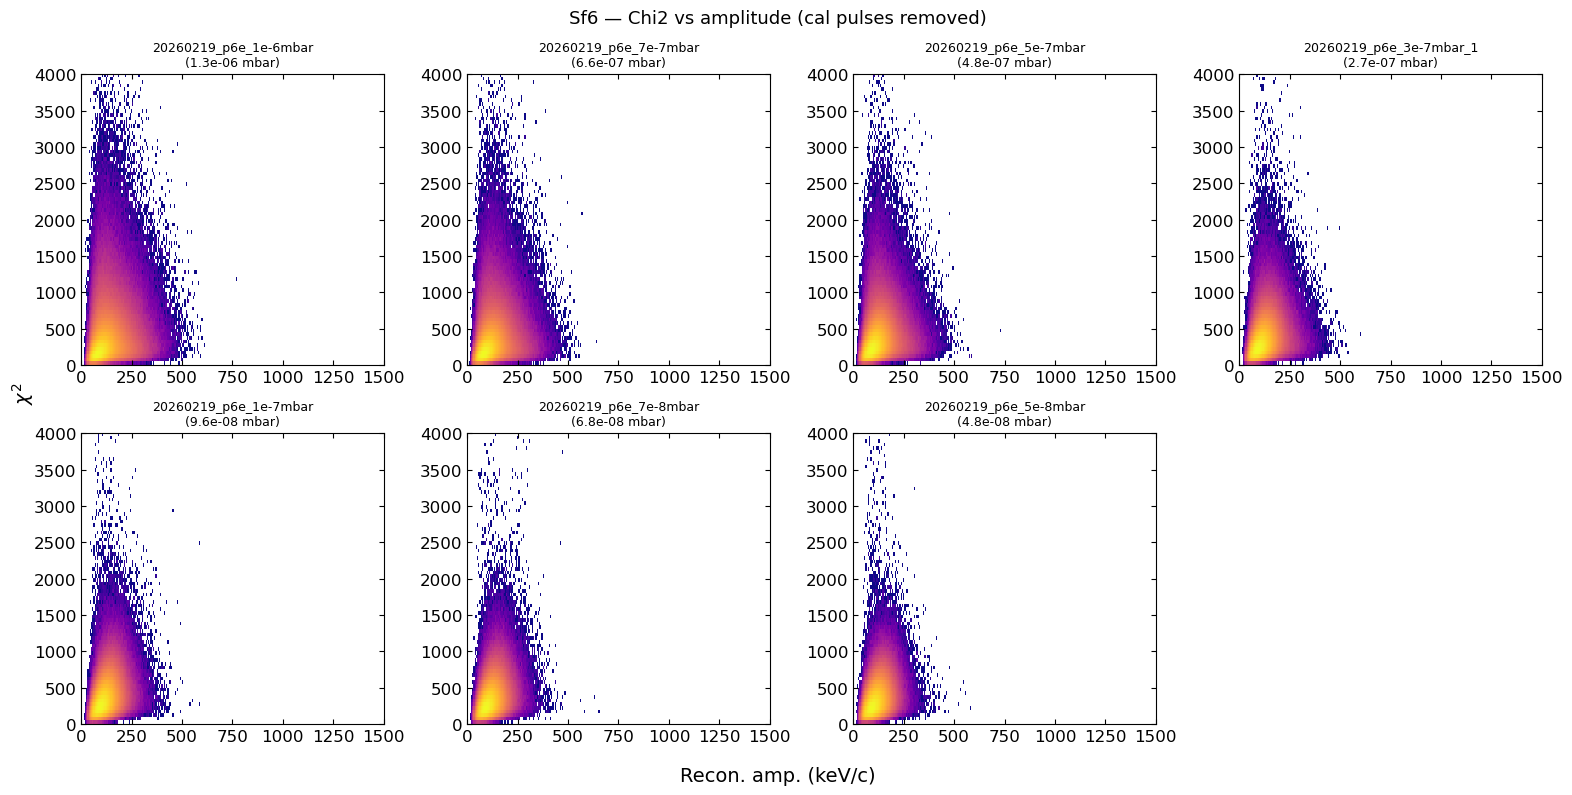

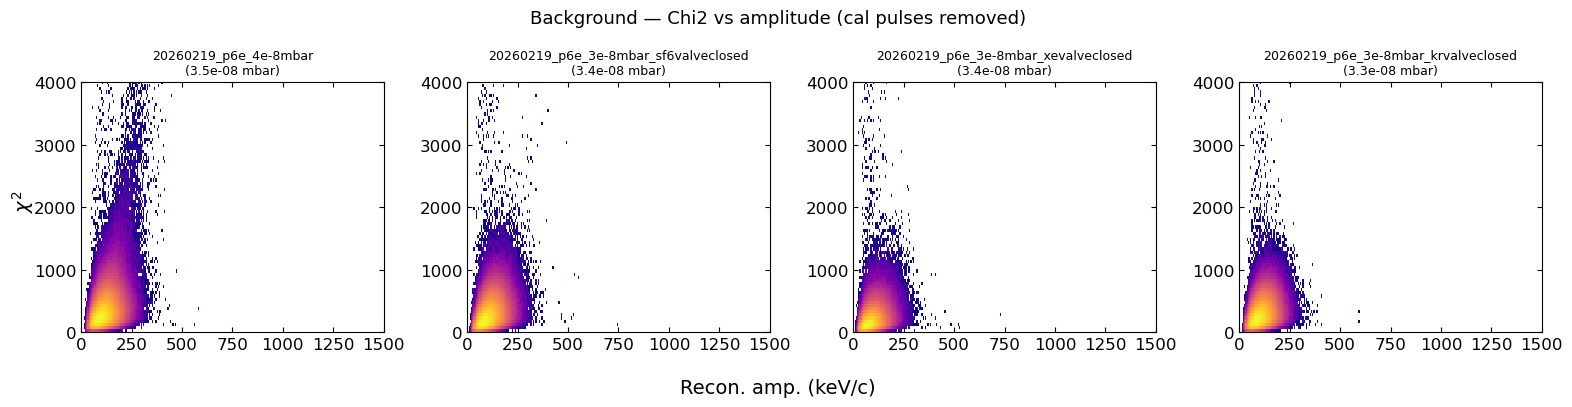

In [49]:
cal_pulse_amp_thr_kev = 500
cal_pulse_offset      = 20   # matches get_search_window() pulse_length=20

def load_amp_chi2_nocal(gas_dir, dataset):
    """Load |amplitude| (keV/c) and chi2 after homodyne, noise, drive cuts,
    with calibration pulses removed using the same flag_cal_pulses logic as
    recon_histograms.py (nearest pulse, symmetric timing window)."""
    amps_kev, chi2s = [], []
    for i in range(nfiles):
        fpath = os.path.join(processed_base, gas_dir, dataset, f'{file_prefix}{i}_processed.hdf5')
        with h5py.File(fpath, 'r') as f:
            g = f['data_processed']
            a2k      = g.attrs['amp2kev']
            good     = g['good_detection'][:]
            noise    = g['noise_level_amp'][:]
            driven   = g['driven_power'][:]
            freq     = g['f_res'][:]
            amp      = g['amplitude'][:]      # (n_windows, n_searches)
            chi2     = g['chisquare'][:]
            idx_win  = g['idx_in_window'][:]
            cal_idx  = g['cal_pulse_indices'][:].astype(np.int64)

        # Per-window quality mask
        norm_drive = driven * (freq**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        window_mask = good & (noise * a2k < noise_threshold_kev) & (norm_drive > normalized_drive_power_threshold)

        # Cal-pulse flag: same logic as recon_histograms.flag_cal_pulses
        n_windows = idx_win.shape[0]
        win_offsets = np.arange(n_windows, dtype=np.int64) * analysis_window_length_gas
        abs_idx = (win_offsets[:, np.newaxis] + idx_win.astype(np.int64)).ravel()

        if cal_idx.size > 0:
            sorted_cal = np.sort(cal_idx)
            # Find nearest cal pulse in either direction
            pos = np.searchsorted(sorted_cal, abs_idx, side='left')
            left_pos  = np.clip(pos - 1, 0, sorted_cal.size - 1)
            right_pos = np.clip(pos,     0, sorted_cal.size - 1)
            left_pulse  = sorted_cal[left_pos]
            right_pulse = sorted_cal[right_pos]
            has_left  = pos > 0
            has_right = pos < sorted_cal.size
            nearest_pulse = np.where(
                has_left & has_right,
                np.where(np.abs(abs_idx - left_pulse) <= np.abs(abs_idx - right_pulse),
                         left_pulse, right_pulse),
                np.where(has_left, left_pulse, right_pulse),
            )
            delta = abs_idx - nearest_pulse
            timing_match = np.abs(delta - cal_pulse_offset) < search_window_length
            amp_match = np.abs(amp.ravel()) * a2k > cal_pulse_amp_thr_kev
            is_cal = (timing_match & amp_match).reshape(idx_win.shape)
        else:
            is_cal = np.zeros(idx_win.shape, dtype=bool)

        # Apply window mask and exclude cal pulses, then flatten
        for j in np.where(window_mask)[0]:
            keep = ~is_cal[j]
            amps_kev.append(np.abs(amp[j][keep]) * a2k)
            chi2s.append(chi2[j][keep])

    return np.concatenate(amps_kev), np.concatenate(chi2s)


xbins = np.linspace(0, 1500, 250)
ybins = np.linspace(0, 10000, 200)

for gas in gas_types:
    gas_dir = gas_dir_map[gas]
    with h5py.File(recon_file, 'r') as f:
        grp = f['recon_histograms'][gas]
        datasets = [k for k in grp if not any(k.endswith(s) for s in _stage_suffixes)]
        superseded = {d[:-2] for d in datasets if d.endswith('_1')}
        datasets = [d for d in datasets if d not in superseded]
        pressures = {d: grp[d].attrs['pressure_mbar'] for d in datasets}
    datasets.sort(key=lambda d: pressures[d], reverse=True)

    ncols = 4
    nrows = max(1, (len(datasets) + ncols - 1) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    axes_flat = np.atleast_1d(axes).flat

    for idx, dataset in enumerate(datasets):
        ax = axes_flat[idx]
        amps_kev, chi2s = load_amp_chi2_nocal(gas_dir, dataset)
        hh, _, _ = np.histogram2d(x=amps_kev, y=chi2s, bins=(xbins, ybins))
        ax.pcolormesh(xbins, ybins, hh.T, norm=mcolors.LogNorm(), cmap='plasma')
        ax.set_title(f'{dataset}\n({pressures[dataset]:.1e} mbar)', fontsize=9)
        ax.set_xlim(0, 1500)
        ax.set_ylim(0, 4000)

    for ax in list(axes_flat)[len(datasets):]:
        ax.set_visible(False)

    fig.supxlabel('Recon. amp. (keV/c)', fontsize=14)
    fig.supylabel(r'$\chi^2$', fontsize=14)
    fig.suptitle(f'{gas.capitalize()} — Chi2 vs amplitude (cal pulses removed)', fontsize=13)
    fig.tight_layout()

## High-chi2 waveforms — Xe =1e-6 mbar (cal pulses removed)

Waveforms for events with chi2 > 2000 in the highest-pressure Xe dataset, after calibration pulses are removed. Red dashed line is the scaled 20V calibration template, aligned so both peak at t = 0.

In [67]:
notch_freq = 137000  # Hz — must match process_gas_data.py (same as drive_freq)

def collect_events(dataset, gas_dir, chi2_lo=0, chi2_hi=np.inf, amp_lo_kev=0, amp_hi_kev=np.inf):
    """Return events passing pre-chi2 quality cuts with cal pulses removed,
    filtered to chi2 >= chi2_lo and amp_lo_kev <= |amp| <= amp_hi_kev.

    Each event is a tuple: (file_i, window_j, search_k, abs_idx, amp_kev, chi2).
    Uses globals: processed_base, file_prefix, nfiles, noise_threshold_kev,
    normalized_drive_power_threshold, drive_freq, ref_freq,
    analysis_window_length_gas, search_window_length,
    cal_pulse_offset, cal_pulse_amp_thr_kev.
    """
    events = []
    for i in range(nfiles):
        fpath = os.path.join(processed_base, gas_dir, dataset,
                             f'{file_prefix}{i}_processed.hdf5')
        with h5py.File(fpath, 'r') as f:
            g = f['data_processed']
            a2k     = g.attrs['amp2kev']
            good    = g['good_detection'][:]
            noise   = g['noise_level_amp'][:]
            driven  = g['driven_power'][:]
            freq    = g['f_res'][:]
            amp     = g['amplitude'][:]
            chi2    = g['chisquare'][:]
            idx_win = g['idx_in_window'][:]
            cal_idx = g['cal_pulse_indices'][:].astype(np.int64)

        norm_drive = driven * (freq**2 - drive_freq**2)**2 / ((ref_freq**2 - drive_freq**2)**2)
        window_mask = (good
                       & (noise * a2k < noise_threshold_kev)
                       & (norm_drive > normalized_drive_power_threshold))

        # Cal-pulse flag — same logic as recon_histograms.flag_cal_pulses
        n_windows   = idx_win.shape[0]
        win_offsets = np.arange(n_windows, dtype=np.int64) * analysis_window_length_gas
        abs_idx_all = (win_offsets[:, np.newaxis] + idx_win.astype(np.int64)).ravel()

        if cal_idx.size > 0:
            sorted_cal  = np.sort(cal_idx)
            pos         = np.searchsorted(sorted_cal, abs_idx_all, side='left')
            left_pos    = np.clip(pos - 1, 0, sorted_cal.size - 1)
            right_pos   = np.clip(pos,     0, sorted_cal.size - 1)
            left_pulse  = sorted_cal[left_pos]
            right_pulse = sorted_cal[right_pos]
            has_left    = pos > 0
            has_right   = pos < sorted_cal.size
            nearest_pulse = np.where(
                has_left & has_right,
                np.where(np.abs(abs_idx_all - left_pulse) <= np.abs(abs_idx_all - right_pulse),
                         left_pulse, right_pulse),
                np.where(has_left, left_pulse, right_pulse),
            )
            delta        = abs_idx_all - nearest_pulse
            timing_match = np.abs(delta - cal_pulse_offset) < search_window_length
            amp_match    = np.abs(amp.ravel()) * a2k > cal_pulse_amp_thr_kev
            is_cal       = (timing_match & amp_match).reshape(idx_win.shape)
        else:
            is_cal = np.zeros(idx_win.shape, dtype=bool)

        for j in np.where(window_mask)[0]:
            for k in range(amp.shape[1]):
                if is_cal[j, k]:
                    continue
                a_kev = abs(amp[j, k]) * a2k
                c     = chi2[j, k]
                if chi2_lo <= c <= chi2_hi and amp_lo_kev <= a_kev <= amp_hi_kev:
                    events.append((i, j, k,
                                   j * analysis_window_length_gas + int(idx_win[j, k]),
                                   a_kev, c))
    return events


def plot_waveforms(dataset, gas_dir, events, n_show=8, title=None):
    """Plot up to n_show waveforms (spread across events list) with template
    and search window overlaid.  Requires LaCie to be mounted.

    Uses globals: processed_base, file_prefix, fs_raw, analysis_window_length_gas,
    search_window_length, bandpass_lb_xe, bandpass_ub_xe, lowpass_order,
    gamma_damping_xe, c_imp_xe, notch_freq.
    """
    raw_data_dir = rf'/Volumes/LaCie/gas_collisions/{gas_dir}/sphere_20260215/{dataset}'
    if not os.path.exists(raw_data_dir):
        print('LaCie not mounted — skipping waveform plots.')
        return
    if len(events) == 0:
        print('No events to plot.')
        return

    n_show   = min(n_show, len(events))
    indices  = np.round(np.linspace(0, len(events) - 1, n_show)).astype(int)
    selected = [events[ii] for ii in indices]

    # Template — same normalization as process_gas_data.py / load_cal_from_npz()
    _cal_npz = np.load(
        r'/Users/yuhan/work/nanospheres/gas_collisions/data_processed/pulse_calibration/'
        r'sphere_20260215/sphere_20260215_impulse_recon_combined.npz')
    template_norm     = (_cal_npz['ps_20v'] / np.max(_cal_npz['ps_20v']))[1250:1750]
    template_peak_idx = np.argmax(template_norm)
    t_template        = (np.arange(500) - template_peak_idx) / fs_raw * 1e6  # µs

    # lb: samples skipped at start of analysis window before search begins
    lb_samples = 2 * search_window_length

    ncols = 4
    nrows = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.5 * nrows))
    axes_flat = np.atleast_1d(axes).flat
    wf_half   = 500  # samples each side for display

    for ax, (file_i, window_j, search_k, abs_idx, a_kev, chi2_val) in zip(axes_flat, selected):
        dtt_f, channels = utils.load_timestreams(
            os.path.join(raw_data_dir, f'{file_prefix}{file_i}.hdf5'), ['D'])
        zz   = channels[0]
        fs_i = int(np.ceil(1 / dtt_f))

        # Preprocessing must match process_gas_data.py exactly
        zz_notched = utils.notch_filtered(zz, fs_i, f0=notch_freq, q=50)
        zz_bp      = utils.bandpass_filtered(zz_notched, fs_i,
                                             bandpass_lb_xe, bandpass_ub_xe,
                                             order=lowpass_order)
        lo_win = window_j * analysis_window_length_gas
        _, amp_lp = utils.recon_force(dtt_f, zz_bp[lo_win : lo_win + analysis_window_length_gas],
                                      bandpass_ub_xe, lowpass_order,
                                      gamma_damping_xe, c_imp_xe)

        with h5py.File(os.path.join(processed_base, gas_dir, dataset,
                                    f'{file_prefix}{file_i}_processed.hdf5'), 'r') as pf:
            a2k_i      = pf['data_processed'].attrs['amp2kev']
            idx_in_win = int(pf['data_processed']['idx_in_window'][window_j, search_k])

        lo_wf = max(0, idx_in_win - wf_half)
        hi_wf = min(amp_lp.size, idx_in_win + wf_half)
        wf    = amp_lp[lo_wf:hi_wf] * a2k_i
        t_wf  = (np.arange(wf.size) - (idx_in_win - lo_wf)) / fs_raw * 1e6  # µs

        # Search window: index k covers [lb + k*swl, lb + (k+1)*swl) within the analysis window
        sw_lo_us = (lb_samples + search_k * search_window_length - idx_in_win) / fs_raw * 1e6
        sw_hi_us = (lb_samples + (search_k + 1) * search_window_length - idx_in_win) / fs_raw * 1e6

        peak_sign = np.sign(amp_lp[idx_in_win])
        ax.axvspan(sw_lo_us, sw_hi_us, alpha=0.15, color='steelblue', label='Search window')
        ax.plot(t_wf, wf, 'k', linewidth=1, label='Recon.')
        ax.plot(t_template, peak_sign * a_kev * template_norm, 'r--',
                linewidth=1.2, alpha=0.8, label='Template')
        ax.axvline(0, color='gray', ls=':', linewidth=0.8)
        ax.set_title(f'file {file_i}, amp={a_kev:.0f} keV/c\nchi2={chi2_val:.0f}', fontsize=9)
        ax.set_xlim(-wf_half / fs_raw * 1e6, wf_half / fs_raw * 1e6)
        ax.grid(ls=':', linewidth=0.5)
        ax.set_xlabel('Time (µs)', fontsize=9)
        ax.set_ylabel('Amp. (keV/c)', fontsize=9)

    axes_flat[0].legend(fontsize=8)
    for ax in list(axes_flat)[n_show:]:
        ax.set_visible(False)
    if title:
        fig.suptitle(title, fontsize=11)
        fig.tight_layout(rect=[0, 0, 1, 0.93])
    else:
        fig.tight_layout()

amp > 500 keV/c, chi2 < 600: 48 events


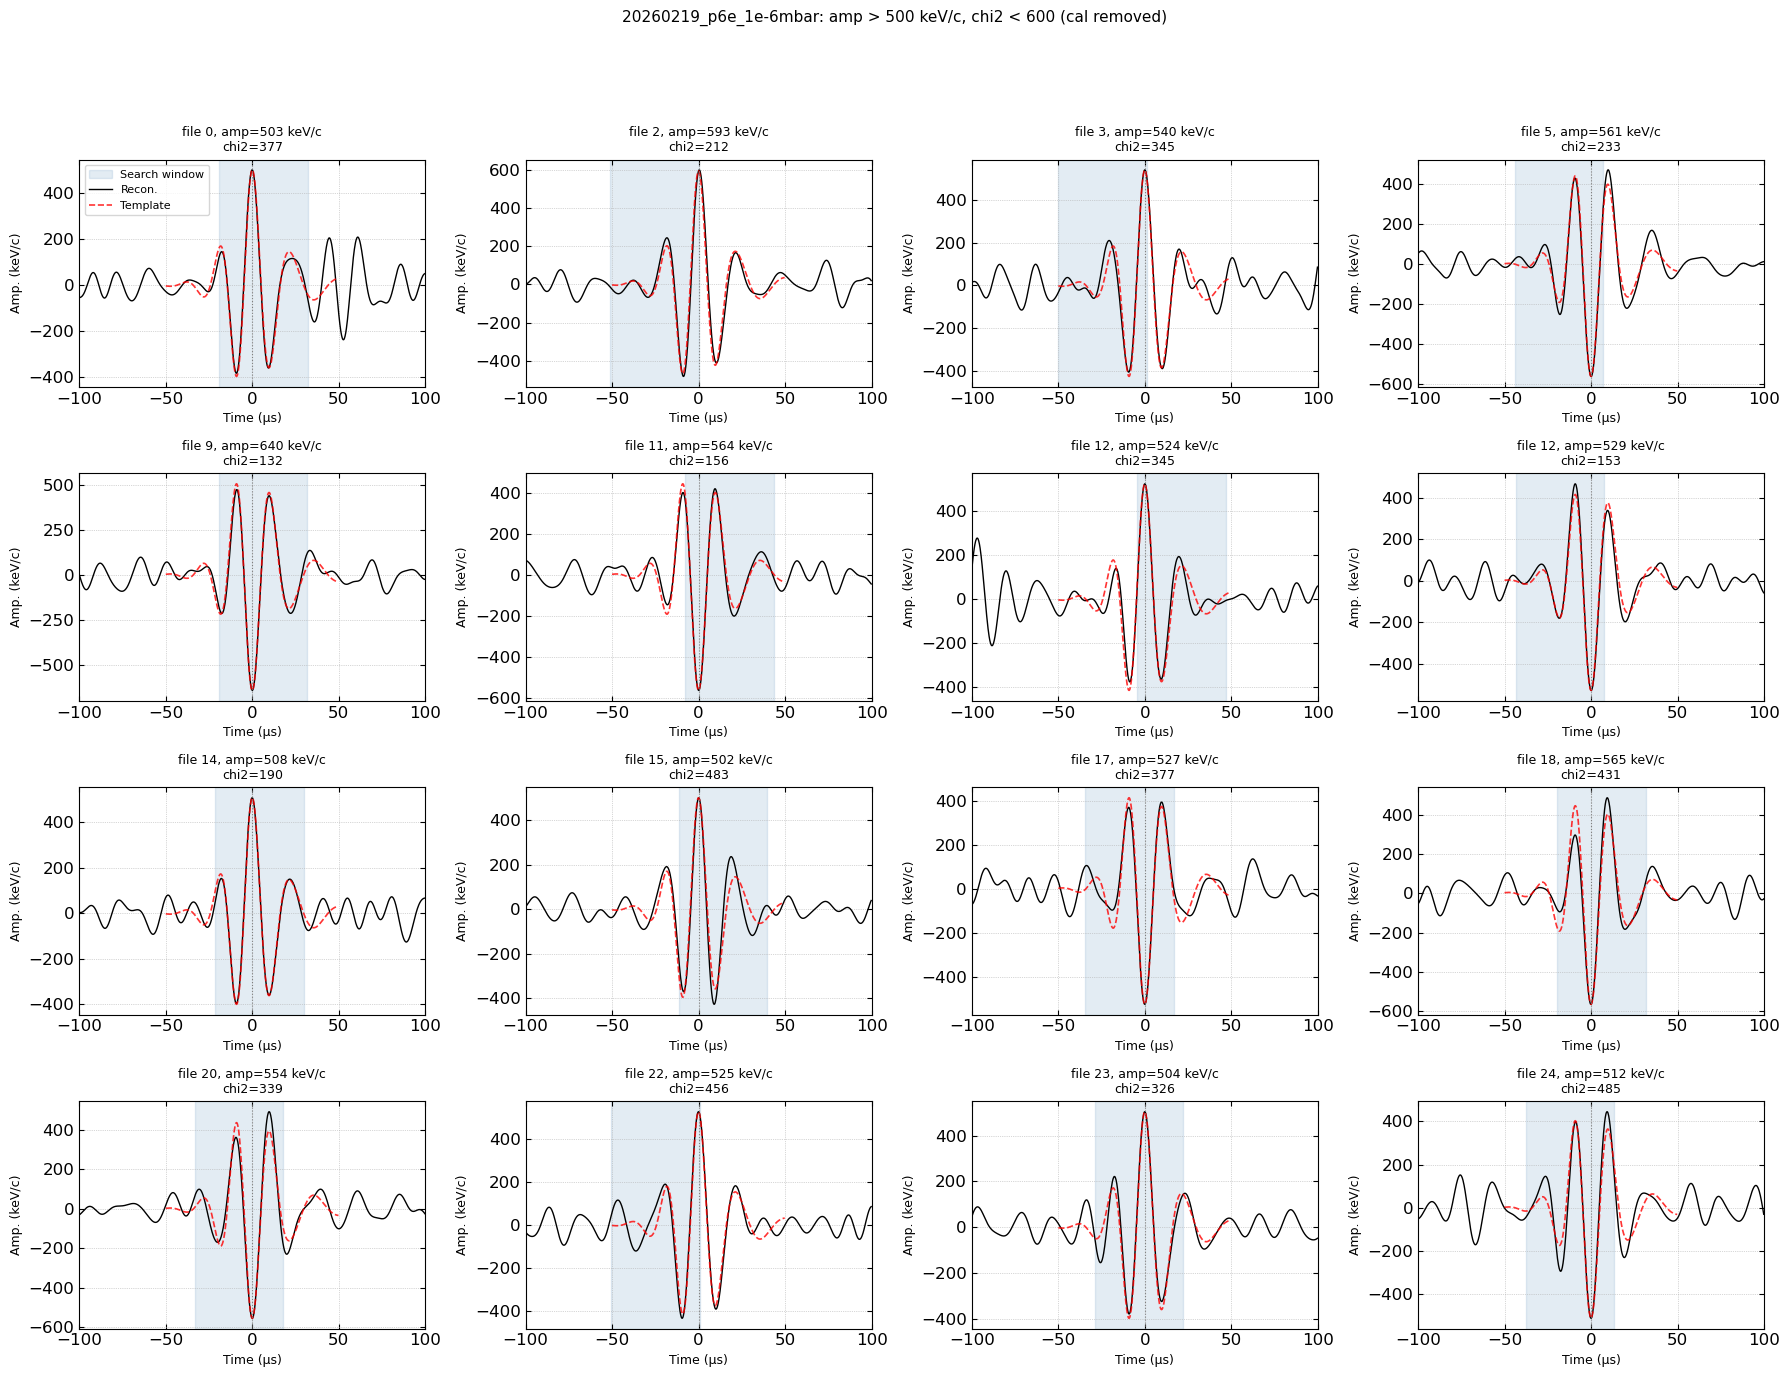

In [ ]:
## Candidate gas collision events
# ── Events above 500 keV/c with chi2 < 600 ───────────────────────────────────────
xe_wf_dataset = '20260219_p6e_1e-6mbar'
gas_dir_xe    = gas_dir_map['xenon']
chi2_hi_events = collect_events(xe_wf_dataset, gas_dir_xe, chi2_lo=0, chi2_hi=600, amp_lo_kev=500)
print(f'amp > 500 keV/c, chi2 < 600: {len(chi2_hi_events)} events')
plot_waveforms(xe_wf_dataset, gas_dir_xe, chi2_hi_events,
               n_show=16,
               title=f'{xe_wf_dataset}: amp > 500 keV/c, chi2 < 600 (cal removed)')

chi2 > 2000: 3708 events


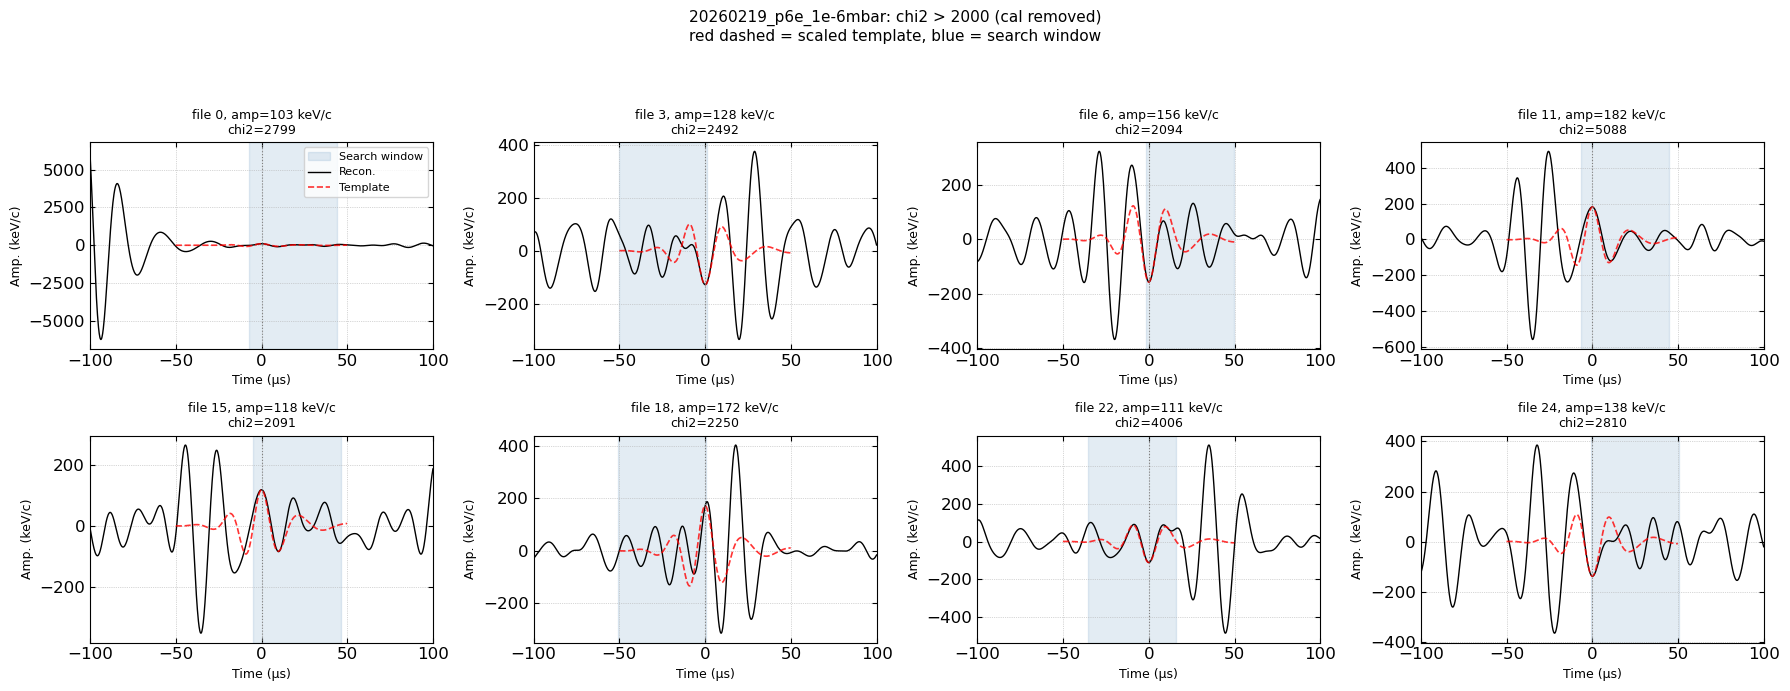

In [68]:
# ── High-chi2 events (chi2 > 2000) ───────────────────────────────────────
xe_wf_dataset = '20260219_p6e_1e-6mbar'
gas_dir_xe    = gas_dir_map['xenon']
chi2_hi_events = collect_events(xe_wf_dataset, gas_dir_xe, chi2_lo=2000)
print(f'chi2 > 2000: {len(chi2_hi_events)} events')
plot_waveforms(xe_wf_dataset, gas_dir_xe, chi2_hi_events,
               title=f'{xe_wf_dataset}: chi2 > 2000 (cal removed)\n'
                     f'red dashed = scaled template, blue = search window')

In [52]:
# ── Events above 500 keV/c with chi2 > 600 ───────────────────────────────
hi_amp_events = collect_events(xe_wf_dataset, gas_dir_xe, chi2_lo=600, amp_lo_kev=500)
print(f'amp > 500 keV/c, chi2 > 600: {len(hi_amp_events)} events')
plot_waveforms(xe_wf_dataset, gas_dir_xe, hi_amp_events,
               n_show=32,
               title=f'{xe_wf_dataset}: amp > 500 keV/c, chi2 > 600 (cal removed)\n'
                     f'red dashed = scaled template, blue = search window')

amp > 500 keV/c, chi2 > 600: 32 events
LaCie not mounted — skipping waveform plots.


In [53]:
# ── Events between 400-500 keV/c with chi2 > 1000 ───────────────────────────────
hi_amp_events = collect_events(xe_wf_dataset, gas_dir_xe, chi2_lo=1000, amp_lo_kev=400, amp_hi_kev=500)
print(f'500 keV/c > amp > 400 keV/c, chi2 > 1000: {len(hi_amp_events)} events')
plot_waveforms(xe_wf_dataset, gas_dir_xe, hi_amp_events,
               n_show=32,
               title=f'{xe_wf_dataset}: 500 keV/c > amp > 400 keV/c, chi2 > 1000 (cal removed)\n'
                     f'red dashed = scaled template, blue = search window')

500 keV/c > amp > 400 keV/c, chi2 > 1000: 126 events
LaCie not mounted — skipping waveform plots.
